# CVFEM 512 reference for Deng--Ginting Example 4, SPE10 coarse-kappa problem

This notebook builds a fine reference for the same coarse-64 permeability/source problem used in the Q1 Deng/NLR/PINN notebook.

Important convention:
- the 64-primal DG0 permeability is replicated `8 x 8` onto the `512 x 512` fine grid;
- the injector/producer source cells are also replicated over the corresponding `8 x 8` fine-cell blocks, preserving the same physical source support and total rates;
- pressure is solved by Q1 vertex-centred CVFEM on the 512-element grid;
- transport is advanced on the corresponding CVFEM nodal dual mesh and then exactly coarsened back to 64 primal cells for comparison.


In [1]:
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve

try:
    from tqdm.auto import tqdm
except ModuleNotFoundError:
    class tqdm:
        def __init__(self, iterable=None, total=None, **kwargs):
            self.iterable = iterable
        def __iter__(self):
            return iter(self.iterable)
        def update(self, n=1):
            pass
        def set_postfix(self, *args, **kwargs):
            pass
        def close(self):
            pass
        def __enter__(self):
            return self
        def __exit__(self, exc_type, exc, tb):
            self.close()
            return False

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

# Fine reference controls.
BASE_NX = 64
BASE_NY = 64
REF_NX = 512
REF_NY = 512
assert REF_NX % BASE_NX == 0 and REF_NY % BASE_NY == 0
REP_X = REF_NX // BASE_NX
REP_Y = REF_NY // BASE_NY

PHI_MATRIX = 1.0
CFL = 0.45
FPRIME_MAX = 2.0
SOURCE_POINTS_REQUESTED = np.array([[0.2, 0.4], [0.8, 0.5]], dtype=float)
SOURCE_RATES = np.array([1.0, -5.0], dtype=float)
SOURCE_SATURATION = 1.0
BOUNDARY_INFLOW_S = 0.0
TRANSPORT_T_VALUES = np.array([0.02, 0.05, 0.1], dtype=float)
TRANSPORT_CLIP = True
TRANSPORT_DT_DIVISOR = 1.0  # set to 2.0 for dt/2, etc.

OUTPUT_BASENAME = "case3_cvfem_reference_spe10_512"

DATA_CANDIDATES = [
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64_wells.mat"),
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64_deng_example4.mat"),
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64_sourcesink.mat"),
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64.mat"),
]
DATA_FILE = None
for candidate in DATA_CANDIDATES:
    if candidate.exists():
        DATA_FILE = candidate
        break
if DATA_FILE is None:
    for candidate in DATA_CANDIDATES:
        matches = sorted(pathlib.Path.cwd().glob(f"**/{candidate.as_posix()}"))
        if matches:
            DATA_FILE = matches[0]
            break
if DATA_FILE is None:
    raise FileNotFoundError("Could not find the 64-cell SPE10/MRST export used by the coarse notebook.")

mrst64 = loadmat(DATA_FILE, squeeze_me=True, struct_as_record=False)
OUTPUT_NPZ = DATA_FILE.parent / f"{OUTPUT_BASENAME}.npz"
OUTPUT_MAT = DATA_FILE.parent / f"{OUTPUT_BASENAME}.mat"
if "kappa_cell" not in mrst64:
    raise KeyError(f"{DATA_FILE} does not contain kappa_cell.")
kappa64 = np.asarray(mrst64["kappa_cell"], dtype=float).reshape(BASE_NY, BASE_NX)
kappa_ref_grid = np.repeat(np.repeat(kappa64, REP_Y, axis=0), REP_X, axis=1)
kappa_ref = kappa_ref_grid.reshape(-1)

xmin = ymin = 0.0
xmax = ymax = 1.0
hx = (xmax - xmin) / REF_NX
hy = (ymax - ymin) / REF_NY
h64x = (xmax - xmin) / BASE_NX
h64y = (ymax - ymin) / BASE_NY
ref_cell_area = hx * hy
coarse_cell_area = h64x * h64y
n_ref_cells = REF_NX * REF_NY
n_ref_nodes = (REF_NX + 1) * (REF_NY + 1)
PV_matrix = PHI_MATRIX * (xmax - xmin) * (ymax - ymin)


def coarse_cell_id_from_point(pt):
    x, y = np.asarray(pt, dtype=float)
    ix = int(np.floor(np.clip((x - xmin) / h64x, 0.0, np.nextafter(float(BASE_NX), 0.0))))
    iy = int(np.floor(np.clip((y - ymin) / h64y, 0.0, np.nextafter(float(BASE_NY), 0.0))))
    return iy * BASE_NX + ix

source_cell_ids64 = np.array([coarse_cell_id_from_point(p) for p in SOURCE_POINTS_REQUESTED], dtype=np.int64)
source_rate_ref = np.zeros(n_ref_cells, dtype=float)
source_rate64 = np.zeros(BASE_NX * BASE_NY, dtype=float)
for cid64, rate in zip(source_cell_ids64, SOURCE_RATES):
    iy64, ix64 = divmod(int(cid64), BASE_NX)
    source_rate64[int(cid64)] += float(rate)
    iy0 = iy64 * REP_Y
    ix0 = ix64 * REP_X
    block_rate = float(rate) / float(REP_X * REP_Y)
    for jy in range(iy0, iy0 + REP_Y):
        start = jy * REF_NX + ix0
        source_rate_ref[start:start + REP_X] += block_rate
source_density_ref = source_rate_ref / ref_cell_area
source_rate_positive = float(np.sum(np.maximum(source_rate_ref, 0.0)))
source_rate_negative = float(np.sum(np.minimum(source_rate_ref, 0.0)))

source_points_effective64 = np.column_stack([
    xmin + (source_cell_ids64 % BASE_NX + 0.5) * h64x,
    ymin + (source_cell_ids64 // BASE_NX + 0.5) * h64y,
])

print(f"Loaded coarse data: {DATA_FILE}")
print(f"Reference grid: {REF_NX} x {REF_NY} elements, {(REF_NX + 1)} x {(REF_NY + 1)} CVFEM nodes")
print(f"kappa convention: 64 DG0 cells replicated {REP_X} x {REP_Y}; range=[{kappa_ref.min():.6g}, {kappa_ref.max():.6g}]")
print("Source/sink convention: same 64-cell support, split uniformly over the fine subcells")
for req, eff, cid, rate in zip(SOURCE_POINTS_REQUESTED, source_points_effective64, source_cell_ids64, SOURCE_RATES):
    print(f"  requested={req}, coarse cell center={eff}, coarse cell={int(cid)}, rate={rate:+.6e}")
print(f"  total source={np.sum(source_rate_ref):+.6e}, positive={source_rate_positive:.6e}, negative={source_rate_negative:.6e}")


Loaded coarse data: case3_ecmor/case3_mrst_export_spe10_L20_64_wells.mat
Reference grid: 512 x 512 elements, 513 x 513 CVFEM nodes
kappa convention: 64 DG0 cells replicated 8 x 8; range=[0.00401984, 409.231]
Source/sink convention: same 64-cell support, split uniformly over the fine subcells
  requested=[0.2 0.4], coarse cell center=[0.1953125 0.3984375], coarse cell=1612, rate=+1.000000e+00
  requested=[0.8 0.5], coarse cell center=[0.8046875 0.5078125], coarse cell=2099, rate=-5.000000e+00
  total source=-4.000000e+00, positive=1.000000e+00, negative=-5.000000e+00


/home/muchamad/PhD/fenicsx/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Structured Q1 CVFEM pressure solve on the fine grid.

def q1_grads_phys(points, hx_val, hy_val):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xi = pts[:, 0] / hx_val
    eta = pts[:, 1] / hy_val
    grads = np.empty((len(pts), 4, 2), dtype=float)
    grads[:, 0, 0] = -(1.0 - eta) / hx_val
    grads[:, 0, 1] = -(1.0 - xi) / hy_val
    grads[:, 1, 0] = (1.0 - eta) / hx_val
    grads[:, 1, 1] = -xi / hy_val
    grads[:, 2, 0] = -eta / hx_val
    grads[:, 2, 1] = (1.0 - xi) / hy_val
    grads[:, 3, 0] = eta / hx_val
    grads[:, 3, 1] = xi / hy_val
    return grads


def segment_flux_basis_local(a, b, normal, hx_val=hx, hy_val=hy, nq=2):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    normal = np.asarray(normal, dtype=float)
    q, w = np.polynomial.legendre.leggauss(max(1, int(nq)))
    q = 0.5 * (q + 1.0)
    w = 0.5 * w
    edge = b - a
    seg_len = float(np.linalg.norm(edge))
    if seg_len <= 0.0:
        return np.zeros(4, dtype=float)
    pts = a[None, :] + q[:, None] * edge[None, :]
    grads = q1_grads_phys(pts, hx_val, hy_val)
    return -seg_len * np.einsum("q,qid,d->i", w, grads, normal)

# Local subfaces of the Q1 nodal dual inside one rectangular element.  Each tuple
# is (owner local node, neighbor local node, segment start, segment end, owner outward normal).
_INTERNAL_SUBFACES = [
    (0, 1, np.array([0.5 * hx, 0.0]),       np.array([0.5 * hx, 0.5 * hy]), np.array([1.0, 0.0])),
    (2, 3, np.array([0.5 * hx, 0.5 * hy]),  np.array([0.5 * hx, hy]),       np.array([1.0, 0.0])),
    (0, 2, np.array([0.0, 0.5 * hy]),       np.array([0.5 * hx, 0.5 * hy]), np.array([0.0, 1.0])),
    (1, 3, np.array([0.5 * hx, 0.5 * hy]),  np.array([hx, 0.5 * hy]),       np.array([0.0, 1.0])),
]
_BOUNDARY_SUBFACES = {
    "bottom": [
        (0, np.array([0.0, 0.0]),      np.array([0.5 * hx, 0.0]), np.array([0.0, -1.0])),
        (1, np.array([0.5 * hx, 0.0]), np.array([hx, 0.0]),       np.array([0.0, -1.0])),
    ],
    "top": [
        (2, np.array([0.0, hy]),       np.array([0.5 * hx, hy]), np.array([0.0, 1.0])),
        (3, np.array([0.5 * hx, hy]),  np.array([hx, hy]),       np.array([0.0, 1.0])),
    ],
    "left": [
        (0, np.array([0.0, 0.0]),      np.array([0.0, 0.5 * hy]), np.array([-1.0, 0.0])),
        (2, np.array([0.0, 0.5 * hy]), np.array([0.0, hy]),       np.array([-1.0, 0.0])),
    ],
    "right": [
        (1, np.array([hx, 0.0]),       np.array([hx, 0.5 * hy]), np.array([1.0, 0.0])),
        (3, np.array([hx, 0.5 * hy]),  np.array([hx, hy]),       np.array([1.0, 0.0])),
    ],
}

Mloc = np.zeros((4, 4), dtype=float)
_internal_basis = []
for owner, neigh, a, b, n in _INTERNAL_SUBFACES:
    basis = segment_flux_basis_local(a, b, n)
    _internal_basis.append((owner, neigh, basis))
    Mloc[owner, :] += basis
    Mloc[neigh, :] -= basis
_boundary_basis = {
    side: [(owner, segment_flux_basis_local(a, b, n)) for owner, a, b, n in items]
    for side, items in _BOUNDARY_SUBFACES.items()
}

ix = np.tile(np.arange(REF_NX, dtype=np.int64), REF_NY)
iy = np.repeat(np.arange(REF_NY, dtype=np.int64), REF_NX)
n0 = iy * (REF_NX + 1) + ix
n1 = n0 + 1
n2 = n0 + (REF_NX + 1)
n3 = n2 + 1
cell_nodes = np.column_stack([n0, n1, n2, n3]).astype(np.int64)

rows = np.repeat(cell_nodes, 4, axis=1).reshape(-1)
cols = np.tile(cell_nodes, (1, 4)).reshape(-1)
vals = (kappa_ref[:, None, None] * Mloc[None, :, :]).reshape(-1)

t0 = time.perf_counter()
A = coo_matrix((vals, (rows, cols)), shape=(n_ref_nodes, n_ref_nodes)).tolil()
b_source = np.zeros(n_ref_nodes, dtype=float)
np.add.at(b_source, cell_nodes.reshape(-1), np.repeat(0.25 * source_rate_ref, 4))
b = b_source.copy()

node_i = np.tile(np.arange(REF_NX + 1, dtype=np.int64), REF_NY + 1)
node_j = np.repeat(np.arange(REF_NY + 1, dtype=np.int64), REF_NX + 1)
boundary_nodes = (node_i == 0) | (node_i == REF_NX) | (node_j == 0) | (node_j == REF_NY)
for idx in np.flatnonzero(boundary_nodes):
    A.rows[int(idx)] = [int(idx)]
    A.data[int(idx)] = [1.0]
    b[int(idx)] = 0.0
A = A.tocsr()
print(f"Assembled CVFEM system: nnz={A.nnz}, time={time.perf_counter() - t0:.2f}s")

t0 = time.perf_counter()
p_ref_nodes = np.asarray(spsolve(A, b), dtype=float)
print(f"Solved CVFEM pressure: time={time.perf_counter() - t0:.2f}s, p range=[{p_ref_nodes.min():+.6e}, {p_ref_nodes.max():+.6e}]")

p_local = p_ref_nodes[cell_nodes]
p_ref_cell = np.mean(p_local, axis=1)
print(f"Cell-center pressure range=[{p_ref_cell.min():+.6e}, {p_ref_cell.max():+.6e}]")


Assembled CVFEM system: nnz=2352137, time=0.88s
Solved CVFEM pressure: time=4.75s, p range=[-7.289550e-01, +3.088083e-01]
Cell-center pressure range=[-7.262802e-01, +3.085885e-01]


In [3]:
# Conservative CVFEM dual fluxes for transport.

def append_faces(owner, neigh, flux, owner_list, neigh_list, flux_list):
    owner_list.append(np.asarray(owner, dtype=np.int64).reshape(-1))
    neigh_list.append(np.asarray(neigh, dtype=np.int64).reshape(-1))
    flux_list.append(np.asarray(flux, dtype=float).reshape(-1))

owner_parts, neigh_parts, flux_parts = [], [], []
for owner_l, neigh_l, basis in _internal_basis:
    F = kappa_ref * (p_local @ basis)
    append_faces(cell_nodes[:, owner_l], cell_nodes[:, neigh_l], F, owner_parts, neigh_parts, flux_parts)

bottom = iy == 0
top = iy == REF_NY - 1
left = ix == 0
right = ix == REF_NX - 1
for owner_l, basis in _boundary_basis["bottom"]:
    F = kappa_ref[bottom] * (p_local[bottom] @ basis)
    append_faces(cell_nodes[bottom, owner_l], -np.ones(np.count_nonzero(bottom), dtype=np.int64), F, owner_parts, neigh_parts, flux_parts)
for owner_l, basis in _boundary_basis["top"]:
    F = kappa_ref[top] * (p_local[top] @ basis)
    append_faces(cell_nodes[top, owner_l], -np.ones(np.count_nonzero(top), dtype=np.int64), F, owner_parts, neigh_parts, flux_parts)
for owner_l, basis in _boundary_basis["left"]:
    F = kappa_ref[left] * (p_local[left] @ basis)
    append_faces(cell_nodes[left, owner_l], -np.ones(np.count_nonzero(left), dtype=np.int64), F, owner_parts, neigh_parts, flux_parts)
for owner_l, basis in _boundary_basis["right"]:
    F = kappa_ref[right] * (p_local[right] @ basis)
    append_faces(cell_nodes[right, owner_l], -np.ones(np.count_nonzero(right), dtype=np.int64), F, owner_parts, neigh_parts, flux_parts)

dual_owner = np.concatenate(owner_parts)
dual_neigh = np.concatenate(neigh_parts)
dual_flux = np.concatenate(flux_parts)
dual_has_neighbor = dual_neigh >= 0
dual_is_boundary = ~dual_has_neighbor

dual_area = np.zeros(n_ref_nodes, dtype=float)
np.add.at(dual_area, cell_nodes.reshape(-1), np.full(cell_nodes.size, 0.25 * ref_cell_area, dtype=float))
dual_pv = PHI_MATRIX * dual_area
dual_source_rate = b_source.copy()

residual = np.zeros(n_ref_nodes, dtype=float)
np.add.at(residual, dual_owner, dual_flux)
np.add.at(residual, dual_neigh[dual_has_neighbor], -dual_flux[dual_has_neighbor])
residual_minus_source = residual - dual_source_rate
interior_nodes = np.flatnonzero(~boundary_nodes)
source_nodes = np.flatnonzero(np.abs(dual_source_rate) > 1.0e-300)

def residual_stats(vals, ids=None):
    arr = np.asarray(vals, dtype=float).reshape(-1)
    if ids is not None:
        arr = arr[np.asarray(ids, dtype=np.int64)]
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return "n=0"
    return (
        f"n={arr.size:d} mean|R|={np.mean(np.abs(arr)):.6e} "
        f"median|R|={np.median(np.abs(arr)):.6e} "
        f"rmse={np.sqrt(np.mean(arr**2)):.6e} "
        f"max|R|={np.max(np.abs(arr)):.6e} sum(R)={np.sum(arr):+.6e}"
    )

print(f"Dual transport mesh: CVs={n_ref_nodes}, subfaces={len(dual_owner)}, boundary subfaces={np.count_nonzero(dual_is_boundary)}")
print("Single-phase dual balance residual sum(outward flux)-source:")
print("  all nodes     :", residual_stats(residual_minus_source))
print("  interior nodes:", residual_stats(residual_minus_source, interior_nodes))
print("  source nodes  :", residual_stats(residual_minus_source, source_nodes))
print(f"  global boundary flux={np.sum(dual_flux[dual_is_boundary]):+.12e}, total source={np.sum(dual_source_rate):+.12e}")


Dual transport mesh: CVs=263169, subfaces=1052672, boundary subfaces=4096
Single-phase dual balance residual sum(outward flux)-source:
  all nodes     : n=263169 mean|R|=3.163962e-09 median|R|=2.122326e-17 rmse=1.521932e-07 max|R|=3.066247e-05 sum(R)=-1.625551e-06
  interior nodes: n=261121 mean|R|=4.699749e-16 median|R|=2.059984e-17 rmse=2.501948e-15 max|R|=1.754455e-13 sum(R)=+5.942352e-12
  source nodes  : n=162 mean|R|=1.161713e-15 median|R|=3.113829e-16 rmse=2.151421e-15 max|R|=1.069977e-14 sum(R)=+3.102640e-14
  global boundary flux=-4.000001625551e+00, total source=-4.000000000000e+00


In [4]:
# Explicit upwind Buckley-Leverett transport on the fine CVFEM dual mesh.

def fractional_flow_bl(S):
    S = np.asarray(S, dtype=float)
    return S ** 2 / (S ** 2 + (1.0 - S) ** 2 + 1.0e-30)


def compute_transport_dt(Fout):
    outflow = np.zeros(n_ref_nodes, dtype=float)
    np.add.at(outflow, dual_owner, np.maximum(Fout, 0.0))
    np.add.at(outflow, dual_neigh[dual_has_neighbor], np.maximum(-Fout[dual_has_neighbor], 0.0))
    outflow += np.abs(dual_source_rate)
    active = (outflow > 1.0e-30) & (dual_pv > 0.0)
    if not np.any(active):
        raise RuntimeError("No active outflow/source terms for transport dt.")
    return CFL * np.min(dual_pv[active] / (FPRIME_MAX * outflow[active]))


def dual_source_water_rate(S):
    out = np.zeros_like(S)
    pos = dual_source_rate > 0.0
    neg = dual_source_rate < 0.0
    out[pos] = dual_source_rate[pos] * fractional_flow_bl(SOURCE_SATURATION)
    out[neg] = dual_source_rate[neg] * fractional_flow_bl(S[neg])
    return out


def advance_transport_snapshots(Fout, times, clip=True, dt_divisor=1.0, show_progress=True):
    times = np.asarray(sorted(np.unique(np.asarray(times, dtype=float))), dtype=float)
    Fout = np.asarray(Fout, dtype=float).reshape(-1)
    dt_cfl = compute_transport_dt(Fout)
    dt_target = dt_cfl / max(float(dt_divisor), 1.0e-300)

    seg_plan = []
    t_prev = 0.0
    for target in times:
        target = float(target)
        nseg = max(1, int(np.ceil((target - t_prev) / dt_target))) if target > t_prev else 0
        seg_plan.append((target, nseg))
        t_prev = target
    total_steps_expected = int(sum(nseg for _, nseg in seg_plan))
    print(
        f"Transport plan: {len(times)} snapshot(s), total steps={total_steps_expected}, "
        f"dt_cfl={dt_cfl:.6e}, target dt={dt_target:.6e}"
    )

    outward = Fout >= 0.0
    incoming_boundary = (~outward) & dual_is_boundary
    up_cv = np.empty_like(dual_owner)
    up_cv[outward] = dual_owner[outward]
    interior_negative = (~outward) & dual_has_neighbor
    up_cv[interior_negative] = dual_neigh[interior_negative]
    up_cv[incoming_boundary] = dual_owner[incoming_boundary]
    boundary_water_flux = fractional_flow_bl(BOUNDARY_INFLOW_S) * Fout

    dt_over_pv = np.zeros_like(dual_pv)
    active_pv = dual_pv > 0.0

    S = np.zeros(n_ref_nodes, dtype=float)
    t_now = 0.0
    cumulative_in = 0.0
    cumulative_out = 0.0
    cumulative_source = 0.0
    clip_mass_delta = 0.0
    clipped_count = 0
    preclip_min = 0.0
    preclip_max = 0.0
    total_steps = 0
    snapshots = {}
    meta = {}

    progress = tqdm(
        total=total_steps_expected,
        desc="Fine CVFEM transport",
        unit="step",
        mininterval=1.0,
        disable=not show_progress,
    )
    try:
        for target, nseg in seg_plan:
            dt = (target - t_now) / nseg if nseg > 0 else 0.0
            if nseg > 0:
                dt_over_pv[active_pv] = dt / dual_pv[active_pv]
            for _ in range(nseg):
                water_flux = fractional_flow_bl(S[up_cv]) * Fout
                water_flux[incoming_boundary] = boundary_water_flux[incoming_boundary]
                wb = water_flux[dual_is_boundary]
                cumulative_in += dt * float(np.sum(np.maximum(-wb, 0.0)))
                cumulative_out += dt * float(np.sum(np.maximum(wb, 0.0)))

                div = np.zeros(n_ref_nodes, dtype=float)
                np.add.at(div, dual_owner, water_flux)
                np.add.at(div, dual_neigh[dual_has_neighbor], -water_flux[dual_has_neighbor])
                sw = dual_source_water_rate(S)
                cumulative_source += dt * float(np.sum(sw))
                S_new = S - dt_over_pv * (div - sw)
                preclip_min = min(preclip_min, float(np.min(S_new)))
                preclip_max = max(preclip_max, float(np.max(S_new)))
                if clip:
                    S_clip = np.clip(S_new, 0.0, 1.0)
                    clipped_count += int(np.count_nonzero(S_clip != S_new))
                    clip_mass_delta += float(np.sum((S_clip - S_new) * dual_pv))
                    S = S_clip
                else:
                    S = S_new
                total_steps += 1
                progress.update(1)
            t_now = target
            mass = float(np.sum(S * dual_pv))
            net = float(cumulative_in - cumulative_out + cumulative_source)
            denom = max(abs(cumulative_source) + cumulative_in, 1.0e-30)
            key = f"T{target:g}"
            snapshots[key] = S.copy()
            meta[key] = {
                "T": target,
                "dt_cfl": float(dt_cfl),
                "dt_target": float(dt_target),
                "last_dt": float(dt),
                "nsteps_total": int(total_steps),
                "pvi": float(target * source_rate_positive / PV_matrix),
                "water_in": float(cumulative_in),
                "water_out": float(cumulative_out),
                "water_source": float(cumulative_source),
                "water_net": float(net),
                "water_mass": float(mass),
                "water_balance_error": float(mass - net),
                "water_balance_error_pct": float(100.0 * (mass - net) / denom),
                "preclip_min": float(preclip_min),
                "preclip_max": float(preclip_max),
                "clip_mass_delta": float(clip_mass_delta),
                "clipped_count": int(clipped_count),
            }
            progress.set_postfix(T=f"{target:.4g}", maxS=f"{np.max(S):.3g}")
    finally:
        progress.close()
    return snapshots, meta

t0 = time.perf_counter()
transport_snapshots, transport_meta = advance_transport_snapshots(
    dual_flux,
    TRANSPORT_T_VALUES,
    clip=TRANSPORT_CLIP,
    dt_divisor=TRANSPORT_DT_DIVISOR,
)
print(f"Transport runtime: {time.perf_counter() - t0:.2f}s")
print(f"Transport clipping enabled: {TRANSPORT_CLIP}; dt divisor={TRANSPORT_DT_DIVISOR:g}")
print("  case       nsteps      last dt      CFL dt      PVI    min(S)    max(S)  preclip min  preclip max    clip dM    balance%")
for key in [f"T{T:g}" for T in sorted(np.unique(TRANSPORT_T_VALUES))]:
    S = transport_snapshots[key]
    m = transport_meta[key]
    print(
        f"  {key:<7} {m['nsteps_total']:8d} {m['last_dt']:12.5e} {m['dt_cfl']:11.5e} {m['pvi']:8.4f} "
        f"{np.min(S):8.3e} {np.max(S):8.3e} {m['preclip_min']:12.3e} {m['preclip_max']:12.3e} "
        f"{m['clip_mass_delta']:11.3e} {m['water_balance_error_pct']:10.3e}"
    )


Transport plan: 3 snapshot(s), total steps=72609, dt_cfl=1.377269e-06, target dt=1.377269e-06


Fine CVFEM transport: 100%|██████████| 72609/72609 [25:12<00:00, 47.99step/s, T=0.1, maxS=0.998] 

Transport runtime: 1427.16s
Transport clipping enabled: True; dt divisor=1
  case       nsteps      last dt      CFL dt      PVI    min(S)    max(S)  preclip min  preclip max    clip dM    balance%
  T0.02      14522  1.37722e-06 1.37727e-06   0.0200 0.000e+00 9.889e-01    0.000e+00    9.889e-01   0.000e+00 -1.025e-11
  T0.05      36305  1.37722e-06 1.37727e-06   0.0500 0.000e+00 9.953e-01    0.000e+00    9.953e-01   0.000e+00 -6.632e-11
  T0.1       72609  1.37726e-06 1.37727e-06   0.1000 0.000e+00 9.976e-01    0.000e+00    9.976e-01   0.000e+00 -5.856e-11


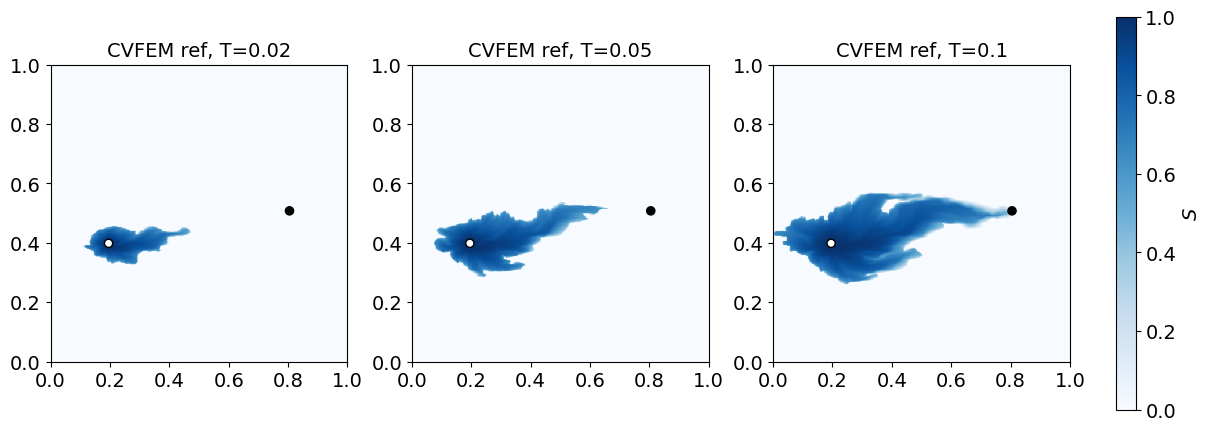

In [5]:
# Plot fine CVFEM-dual saturation snapshots.

def dual_field_to_grid(S):
    return np.asarray(S, dtype=float).reshape((REF_NY + 1, REF_NX + 1))

plot_keys = [f"T{T:g}" for T in sorted(np.unique(TRANSPORT_T_VALUES))]
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, len(plot_keys), figsize=(max(4.0 * len(plot_keys), 5.0), 4.2), squeeze=False, constrained_layout=True)
    axes = axes[0]
    im = None
    x_nodes_ref = np.linspace(xmin, xmax, REF_NX + 1)
    y_nodes_ref = np.linspace(ymin, ymax, REF_NY + 1)
    for ax, key in zip(axes, plot_keys):
        im = ax.pcolormesh(x_nodes_ref, y_nodes_ref, dual_field_to_grid(transport_snapshots[key]), shading="auto", cmap="Blues", vmin=0.0, vmax=1.0)
        ax.scatter(source_points_effective64[:, 0], source_points_effective64[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
        ax.set_title(f"CVFEM ref, T={transport_meta[key]['T']:g}")
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.grid(False)
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.03)
    cbar.set_label(r"$S$")
    plt.show()


Coarsening weight area check: min=2.44140625e-04, max=2.44140625e-04, target=2.44140625e-04


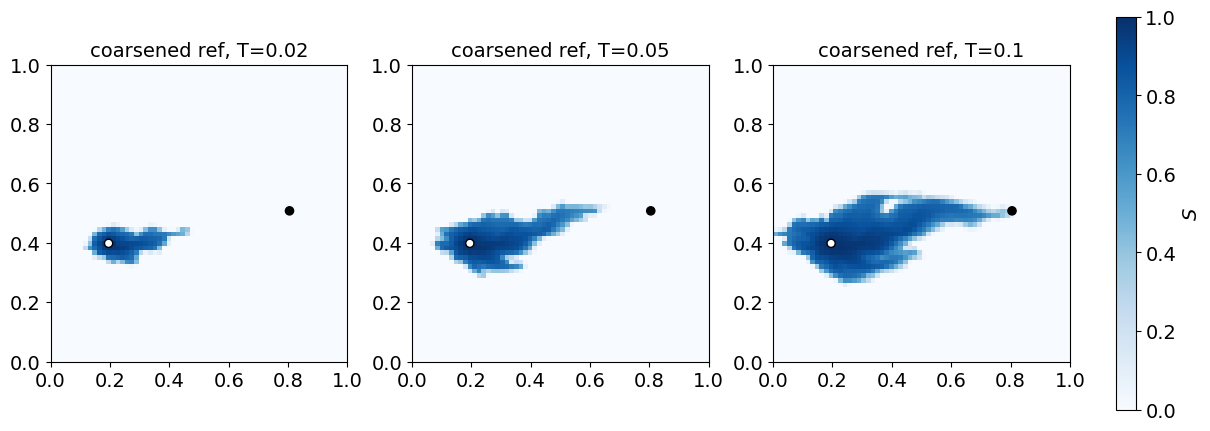

Coarsened 64-cell reference saturation range:
  T0.02   min=0.000000e+00, max=9.884793e-01, mean=2.000000e-02
  T0.05   min=0.000000e+00, max=9.951673e-01, mean=5.000000e-02
  T0.1    min=0.000000e+00, max=9.975348e-01, mean=9.262973e-02


In [6]:
# Exact area-weighted coarsening from the fine nodal-dual CV field to 64 primal cells.

def dual_interval_edges(n, h):
    centers = np.linspace(0.0, 1.0, n + 1)
    left = np.maximum(0.0, centers - 0.5 * h)
    right = np.minimum(1.0, centers + 0.5 * h)
    return left, right


def overlap_matrix_dual_to_coarse(n_fine, n_coarse):
    h_f = 1.0 / n_fine
    h_c = 1.0 / n_coarse
    left, right = dual_interval_edges(n_fine, h_f)
    W = np.zeros((n_coarse, n_fine + 1), dtype=float)
    for j in range(n_coarse):
        c0 = j * h_c
        c1 = (j + 1) * h_c
        W[j, :] = np.maximum(0.0, np.minimum(right, c1) - np.maximum(left, c0))
    return W

Wx64 = overlap_matrix_dual_to_coarse(REF_NX, BASE_NX)
Wy64 = overlap_matrix_dual_to_coarse(REF_NY, BASE_NY)
_weight_area = Wy64 @ np.ones((REF_NY + 1, REF_NX + 1), dtype=float) @ Wx64.T
print(f"Coarsening weight area check: min={_weight_area.min():.8e}, max={_weight_area.max():.8e}, target={coarse_cell_area:.8e}")


def coarsen_dual_to_64(S_dual):
    Sg = dual_field_to_grid(S_dual)
    C = (Wy64 @ Sg @ Wx64.T) / coarse_cell_area
    return C

S_ref64_by_key = {key: coarsen_dual_to_64(S) for key, S in transport_snapshots.items()}

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, len(plot_keys), figsize=(max(4.0 * len(plot_keys), 5.0), 4.2), squeeze=False, constrained_layout=True)
    axes = axes[0]
    im = None
    x64_edges = np.linspace(0.0, 1.0, BASE_NX + 1)
    y64_edges = np.linspace(0.0, 1.0, BASE_NY + 1)
    for ax, key in zip(axes, plot_keys):
        im = ax.pcolormesh(x64_edges, y64_edges, S_ref64_by_key[key], shading="flat", cmap="Blues", vmin=0.0, vmax=1.0)
        ax.scatter(source_points_effective64[:, 0], source_points_effective64[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
        ax.set_title(f"coarsened ref, T={transport_meta[key]['T']:g}")
        ax.set_aspect("equal")
        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(0.0, 1.0)
        ax.grid(False)
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.03)
    cbar.set_label(r"$S$")
    plt.show()

print("Coarsened 64-cell reference saturation range:")
for key in plot_keys:
    C = S_ref64_by_key[key]
    print(f"  {key:<7} min={np.min(C):.6e}, max={np.max(C):.6e}, mean={np.mean(C):.6e}")


In [7]:
# Save the fine and coarsened reference solution.
OUTPUT_NPZ.parent.mkdir(parents=True, exist_ok=True)
keys_sorted = plot_keys
S_ref_dual = np.vstack([transport_snapshots[k].reshape(1, -1) for k in keys_sorted])
S_ref64 = np.vstack([S_ref64_by_key[k].reshape(1, -1) for k in keys_sorted])
T_values_sorted = np.array([transport_meta[k]["T"] for k in keys_sorted], dtype=float)
meta_nsteps = np.array([transport_meta[k]["nsteps_total"] for k in keys_sorted], dtype=np.int64)
meta_last_dt = np.array([transport_meta[k]["last_dt"] for k in keys_sorted], dtype=float)
meta_balance_pct = np.array([transport_meta[k]["water_balance_error_pct"] for k in keys_sorted], dtype=float)

np.savez_compressed(
    OUTPUT_NPZ,
    kappa64=kappa64.reshape(-1),
    kappa_ref=kappa_ref,
    p_ref_nodes=p_ref_nodes,
    p_ref_cell=p_ref_cell,
    dual_owner=dual_owner,
    dual_neigh=dual_neigh,
    dual_flux=dual_flux,
    dual_pv=dual_pv,
    dual_source_rate=dual_source_rate,
    S_ref_dual=S_ref_dual,
    S_ref64=S_ref64,
    T_values=T_values_sorted,
    meta_nsteps=meta_nsteps,
    meta_last_dt=meta_last_dt,
    meta_dt_cfl=np.array([transport_meta[keys_sorted[0]]["dt_cfl"]], dtype=float),
    meta_balance_pct=meta_balance_pct,
    source_points_requested=SOURCE_POINTS_REQUESTED,
    source_points_effective64=source_points_effective64,
    source_cell_ids64=source_cell_ids64,
    source_rates=SOURCE_RATES,
    base_shape=np.array([BASE_NY, BASE_NX], dtype=np.int64),
    ref_shape=np.array([REF_NY, REF_NX], dtype=np.int64),
    ref_node_shape=np.array([REF_NY + 1, REF_NX + 1], dtype=np.int64),
)

savemat(
    OUTPUT_MAT,
    {
        "kappa64": kappa64,
        "p_ref_nodes": p_ref_nodes.reshape(REF_NY + 1, REF_NX + 1),
        "p_ref_cell": p_ref_cell.reshape(REF_NY, REF_NX),
        "S_ref_dual": S_ref_dual,
        "S_ref64": S_ref64,
        "T_values": T_values_sorted,
        "meta_nsteps": meta_nsteps,
        "meta_last_dt": meta_last_dt,
        "meta_dt_cfl": np.array([transport_meta[keys_sorted[0]]["dt_cfl"]], dtype=float),
        "meta_balance_pct": meta_balance_pct,
        "source_points_requested": SOURCE_POINTS_REQUESTED,
        "source_points_effective64": source_points_effective64,
        "source_cell_ids64": source_cell_ids64 + 1,  # MATLAB one-based convenience
        "source_rates": SOURCE_RATES,
        "README": np.array("CVFEM 512 reference; 64-cell P0 kappa replicated 8x8; sources use same 64-cell support."),
    },
    do_compression=True,
)

print(f"Saved full reference: {OUTPUT_NPZ}")
print(f"Saved compact MATLAB reference: {OUTPUT_MAT}")


Saved full reference: case3_ecmor/case3_cvfem_reference_spe10_512.npz
Saved compact MATLAB reference: case3_ecmor/case3_cvfem_reference_spe10_512.mat


In [1]:
# ORACLE PART 1: CVFEM pressure on 576^2 elements.
# Self-contained setup: run this cell, then ORACLE PART 2 and 3, without executing the 512-reference cells above.
# 576/64 = 9 (ODD ratio) => the 577^2 dual faces nest exactly with the 65^2 coarse dual faces.
# This run exists ONLY to donate its flux; no fine transport is performed.
import pathlib
import time
import numpy as np
from scipy.io import loadmat, savemat
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve

BASE_NX = 64
BASE_NY = 64
SOURCE_POINTS_REQUESTED = np.array([[0.2, 0.4], [0.8, 0.5]], dtype=float)
SOURCE_RATES = np.array([1.0, -5.0], dtype=float)

DATA_CANDIDATES = [
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64_wells.mat"),
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64_deng_example4.mat"),
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64_sourcesink.mat"),
    pathlib.Path("case3_ecmor/case3_mrst_export_spe10_L20_64.mat"),
    pathlib.Path("fenicsx/code/fracture problem/case3_ecmor/case3_mrst_export_spe10_L20_64_wells.mat"),
    pathlib.Path("fenicsx/code/fracture problem/case3_ecmor/case3_mrst_export_spe10_L20_64_deng_example4.mat"),
    pathlib.Path("fenicsx/code/fracture problem/case3_ecmor/case3_mrst_export_spe10_L20_64_sourcesink.mat"),
    pathlib.Path("fenicsx/code/fracture problem/case3_ecmor/case3_mrst_export_spe10_L20_64.mat"),
]
DATA_FILE = None
for candidate in DATA_CANDIDATES:
    if candidate.exists():
        DATA_FILE = candidate
        break
if DATA_FILE is None:
    for candidate in DATA_CANDIDATES:
        matches = sorted(pathlib.Path.cwd().glob(f"**/{candidate.name}"))
        if matches:
            DATA_FILE = matches[0]
            break
if DATA_FILE is None:
    raise FileNotFoundError("Could not find the 64-cell SPE10/MRST export used by the coarse notebook.")

mrst64 = loadmat(DATA_FILE, squeeze_me=True, struct_as_record=False)
if "kappa_cell" not in mrst64:
    raise KeyError(f"{DATA_FILE} does not contain kappa_cell.")
kappa64 = np.asarray(mrst64["kappa_cell"], dtype=float).reshape(BASE_NY, BASE_NX)

xmin = ymin = 0.0
xmax = ymax = 1.0
h64x = (xmax - xmin) / BASE_NX
h64y = (ymax - ymin) / BASE_NY


def coarse_cell_id_from_point(pt):
    x, y = np.asarray(pt, dtype=float)
    ix = int(np.floor(np.clip((x - xmin) / h64x, 0.0, np.nextafter(float(BASE_NX), 0.0))))
    iy = int(np.floor(np.clip((y - ymin) / h64y, 0.0, np.nextafter(float(BASE_NY), 0.0))))
    return iy * BASE_NX + ix


source_cell_ids64 = np.array([coarse_cell_id_from_point(p) for p in SOURCE_POINTS_REQUESTED], dtype=np.int64)


def q1_grads_phys(points, hx_val, hy_val):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xi = pts[:, 0] / hx_val
    eta = pts[:, 1] / hy_val
    grads = np.empty((len(pts), 4, 2), dtype=float)
    grads[:, 0, 0] = -(1.0 - eta) / hx_val
    grads[:, 0, 1] = -(1.0 - xi) / hy_val
    grads[:, 1, 0] = (1.0 - eta) / hx_val
    grads[:, 1, 1] = -xi / hy_val
    grads[:, 2, 0] = -eta / hx_val
    grads[:, 2, 1] = (1.0 - xi) / hy_val
    grads[:, 3, 0] = eta / hx_val
    grads[:, 3, 1] = xi / hy_val
    return grads


def segment_flux_basis_local(a, b, normal, hx_val=None, hy_val=None, nq=2):
    if hx_val is None:
        hx_val = globals().get("hx", h64x)
    if hy_val is None:
        hy_val = globals().get("hy", h64y)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    normal = np.asarray(normal, dtype=float)
    q, w = np.polynomial.legendre.leggauss(max(1, int(nq)))
    q = 0.5 * (q + 1.0)
    w = 0.5 * w
    edge = b - a
    seg_len = float(np.linalg.norm(edge))
    if seg_len <= 0.0:
        return np.zeros(4, dtype=float)
    pts = a[None, :] + q[:, None] * edge[None, :]
    grads = q1_grads_phys(pts, hx_val, hy_val)
    return -seg_len * np.einsum("q,qid,d->i", w, grads, normal)


def residual_stats(vals, ids=None):
    arr = np.asarray(vals, dtype=float).reshape(-1)
    if ids is not None:
        arr = arr[np.asarray(ids, dtype=np.int64)]
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return "n=0"
    return (
        f"n={arr.size:d} mean|R|={np.mean(np.abs(arr)):.6e} "
        f"median|R|={np.median(np.abs(arr)):.6e} "
        f"rmse={np.sqrt(np.mean(arr**2)):.6e} "
        f"max|R|={np.max(np.abs(arr)):.6e} sum(R)={np.sum(arr):+.6e}"
    )

print(f"Oracle setup loaded coarse data: {DATA_FILE}")
print(f"  kappa64 range=[{kappa64.min():.6g}, {kappa64.max():.6g}], sources={list(zip(source_cell_ids64.tolist(), SOURCE_RATES.tolist()))}")

ORC_NX = ORC_NY = 576
assert ORC_NX % BASE_NX == 0 and (ORC_NX // BASE_NX) % 2 == 1, "oracle grid must be an ODD multiple of 64"
ORC_REP = ORC_NX // BASE_NX  # 9
orc_hx = (xmax - xmin) / ORC_NX
orc_hy = (ymax - ymin) / ORC_NY
orc_n_cells = ORC_NX * ORC_NY
orc_n_nodes = (ORC_NX + 1) * (ORC_NY + 1)
orc_kappa = np.repeat(np.repeat(kappa64, ORC_REP, axis=0), ORC_REP, axis=1).reshape(-1)

orc_source_rate = np.zeros(orc_n_cells, dtype=float)
for cid64, rate in zip(source_cell_ids64, SOURCE_RATES):
    iy64, ix64 = divmod(int(cid64), BASE_NX)
    block = float(rate) / float(ORC_REP * ORC_REP)
    for jy in range(iy64 * ORC_REP, (iy64 + 1) * ORC_REP):
        s = jy * ORC_NX + ix64 * ORC_REP
        orc_source_rate[s:s + ORC_REP] += block

def orc_seg_basis(a, b, normal, nq=2):
    return segment_flux_basis_local(a, b, normal, hx_val=orc_hx, hy_val=orc_hy, nq=nq)

_ORC_INTERNAL = [
    (0, 1, np.array([0.5*orc_hx, 0.0]),        np.array([0.5*orc_hx, 0.5*orc_hy]), np.array([1.0, 0.0])),
    (2, 3, np.array([0.5*orc_hx, 0.5*orc_hy]), np.array([0.5*orc_hx, orc_hy]),     np.array([1.0, 0.0])),
    (0, 2, np.array([0.0, 0.5*orc_hy]),        np.array([0.5*orc_hx, 0.5*orc_hy]), np.array([0.0, 1.0])),
    (1, 3, np.array([0.5*orc_hx, 0.5*orc_hy]), np.array([orc_hx, 0.5*orc_hy]),     np.array([0.0, 1.0])),
]
orc_Mloc = np.zeros((4, 4), dtype=float)
for _ow, _ne, _a, _b, _n in _ORC_INTERNAL:
    _bas = orc_seg_basis(_a, _b, _n)
    orc_Mloc[_ow, :] += _bas
    orc_Mloc[_ne, :] -= _bas

orc_ix = np.tile(np.arange(ORC_NX, dtype=np.int64), ORC_NY)
orc_iy = np.repeat(np.arange(ORC_NY, dtype=np.int64), ORC_NX)
_orc_n0 = orc_iy * (ORC_NX + 1) + orc_ix
orc_cell_nodes = np.column_stack([_orc_n0, _orc_n0 + 1,
                                  _orc_n0 + (ORC_NX + 1), _orc_n0 + (ORC_NX + 2)]).astype(np.int64)

_rows = np.repeat(orc_cell_nodes, 4, axis=1).reshape(-1)
_cols = np.tile(orc_cell_nodes, (1, 4)).reshape(-1)
_vals = (orc_kappa[:, None, None] * orc_Mloc[None, :, :]).reshape(-1)
t0 = time.perf_counter()
orc_A = coo_matrix((_vals, (_rows, _cols)), shape=(orc_n_nodes, orc_n_nodes)).tolil()
orc_b = np.zeros(orc_n_nodes, dtype=float)
np.add.at(orc_b, orc_cell_nodes.reshape(-1), np.repeat(0.25 * orc_source_rate, 4))
_ni = np.tile(np.arange(ORC_NX + 1, dtype=np.int64), ORC_NY + 1)
_nj = np.repeat(np.arange(ORC_NY + 1, dtype=np.int64), ORC_NX + 1)
orc_boundary_nodes = (_ni == 0) | (_ni == ORC_NX) | (_nj == 0) | (_nj == ORC_NY)
for _idx in np.flatnonzero(orc_boundary_nodes):
    orc_A.rows[int(_idx)] = [int(_idx)]
    orc_A.data[int(_idx)] = [1.0]
    orc_b[int(_idx)] = 0.0
orc_p = np.asarray(spsolve(orc_A.tocsr(), orc_b), dtype=float)
orc_p_local = orc_p[orc_cell_nodes]
print(f"Oracle CVFEM 576^2 solved in {time.perf_counter() - t0:.1f}s, p range=[{orc_p.min():+.4e}, {orc_p.max():+.4e}]")


Oracle setup loaded coarse data: case3_ecmor/case3_mrst_export_spe10_L20_64_wells.mat
  kappa64 range=[0.00401984, 409.231], sources=[(1612, 1.0), (2099, -5.0)]
Oracle CVFEM 576^2 solved in 6.7s, p range=[-7.2899e-01, +3.1058e-01]


In [5]:
# ORACLE PART 2: integrate -kappa grad(p_h).n over each 65x65 coarse dual face (exact, nested).
def _orc_vface_flux(J, ylo, yhi):
    i_f = 9 * J + 4                       # fine element column whose midline is the coarse face
    F = 0.0
    m0 = int(np.floor(ylo / orc_hy + 1e-12)); m1 = int(np.ceil(yhi / orc_hy - 1e-12))
    for m in range(max(0, m0), min(ORC_NY, m1)):
        s0, s1 = max(ylo, m * orc_hy), min(yhi, (m + 1) * orc_hy)
        if s1 - s0 <= 1e-15:
            continue
        cell = m * ORC_NX + i_f
        F += orc_kappa[cell] * float(orc_p_local[cell] @ orc_seg_basis(
            np.array([0.5*orc_hx, s0 - m*orc_hy]), np.array([0.5*orc_hx, s1 - m*orc_hy]), np.array([1.0, 0.0])))
    return F

def _orc_hface_flux(K, xlo, xhi):
    m_f = 9 * K + 4
    F = 0.0
    i0 = int(np.floor(xlo / orc_hx + 1e-12)); i1 = int(np.ceil(xhi / orc_hx - 1e-12))
    for i in range(max(0, i0), min(ORC_NX, i1)):
        s0, s1 = max(xlo, i * orc_hx), min(xhi, (i + 1) * orc_hx)
        if s1 - s0 <= 1e-15:
            continue
        cell = m_f * ORC_NX + i
        F += orc_kappa[cell] * float(orc_p_local[cell] @ orc_seg_basis(
            np.array([s0 - i*orc_hx, 0.5*orc_hy]), np.array([s1 - i*orc_hx, 0.5*orc_hy]), np.array([0.0, 1.0])))
    return F

def _orc_bface_flux(side, idx, lo, hi):
    F = 0.0
    for m in range(max(0, int(np.floor(lo/orc_hy + 1e-12))), min(ORC_NY if side in ("L","R") else ORC_NX,
                   int(np.ceil(hi/(orc_hy if side in ("L","R") else orc_hx) - 1e-12)))):
        h_ = orc_hy if side in ("L", "R") else orc_hx
        s0, s1 = max(lo, m * h_), min(hi, (m + 1) * h_)
        if s1 - s0 <= 1e-15:
            continue
        if side == "L":
            cell, a, b, n = m*ORC_NX, [0.0, s0-m*h_], [0.0, s1-m*h_], [-1.0, 0.0]
        elif side == "R":
            cell, a, b, n = m*ORC_NX + ORC_NX-1, [orc_hx, s0-m*h_], [orc_hx, s1-m*h_], [1.0, 0.0]
        elif side == "B":
            cell, a, b, n = m, [s0-m*h_, 0.0], [s1-m*h_, 0.0], [0.0, -1.0]
        else:
            cell, a, b, n = (ORC_NY-1)*ORC_NX + m, [s0-m*h_, orc_hy], [s1-m*h_, orc_hy], [0.0, 1.0]
        F += orc_kappa[cell] * float(orc_p_local[cell] @ orc_seg_basis(np.array(a), np.array(b), np.array(n)))
    return F

NB = BASE_NX  # 64
_nid = lambda J, K: K * (NB + 1) + J          # coarse node id, x-fastest (matches main notebook)
_span = lambda K, h: (max(0.0, (K - 0.5) * h), min(1.0, (K + 0.5) * h))
fp1, fp2, fnrm, fown, fnei, fflx = [], [], [], [], [], []
for K in range(NB + 1):                        # interior vertical faces
    ylo, yhi = _span(K, h64y)
    for J in range(NB):
        x = (J + 0.5) * h64x
        fp1.append([x, ylo]); fp2.append([x, yhi]); fnrm.append([1.0, 0.0])
        fown.append(_nid(J, K)); fnei.append(_nid(J + 1, K)); fflx.append(_orc_vface_flux(J, ylo, yhi))
for J in range(NB + 1):                        # interior horizontal faces
    xlo, xhi = _span(J, h64x)
    for K in range(NB):
        y = (K + 0.5) * h64y
        fp1.append([xlo, y]); fp2.append([xhi, y]); fnrm.append([0.0, 1.0])
        fown.append(_nid(J, K)); fnei.append(_nid(J, K + 1)); fflx.append(_orc_hface_flux(K, xlo, xhi))
for K in range(NB + 1):                        # boundary faces (outward positive)
    ylo, yhi = _span(K, h64y)
    for side, J, nx_ in (("L", 0, [-1.0, 0.0]), ("R", NB, [1.0, 0.0])):
        x = 0.0 if side == "L" else 1.0
        fp1.append([x, ylo]); fp2.append([x, yhi]); fnrm.append(nx_)
        fown.append(_nid(J, K)); fnei.append(-1); fflx.append(_orc_bface_flux(side, K, ylo, yhi))
for J in range(NB + 1):
    xlo, xhi = _span(J, h64x)
    for side, K, ny_ in (("B", 0, [0.0, -1.0]), ("T", NB, [0.0, 1.0])):
        y = 0.0 if side == "B" else 1.0
        fp1.append([xlo, y]); fp2.append([xhi, y]); fnrm.append(ny_)
        fown.append(_nid(J, K)); fnei.append(-1); fflx.append(_orc_bface_flux(side, J, xlo, xhi))

fp1, fp2 = np.asarray(fp1), np.asarray(fp2)
fnrm, fflx = np.asarray(fnrm), np.asarray(fflx)
fown, fnei = np.asarray(fown, dtype=np.int64), np.asarray(fnei, dtype=np.int64)
assert len(fflx) == 2 * NB * (NB + 1) + 4 * (NB + 1)  # 8580

# conservation audit on the coarse dual CVs (quarter-rate sources at well-cell corner nodes)
orc_src65 = np.zeros((NB + 1) ** 2)
for cid64, rate in zip(source_cell_ids64, SOURCE_RATES):
    iy64, ix64 = divmod(int(cid64), NB)
    for dj in (0, 1):
        for dk in (0, 1):
            orc_src65[_nid(ix64 + dj, iy64 + dk)] += 0.25 * float(rate)

def _coarse_dual_residual(face_flux):
    res = np.zeros((NB + 1) ** 2)
    np.add.at(res, fown, face_flux)
    has = fnei >= 0
    np.add.at(res, fnei[has], -face_flux[has])
    res -= orc_src65
    return res

_has = fnei >= 0
orc_raw_fflx = fflx.copy()
orc_raw_res = _coarse_dual_residual(orc_raw_fflx)

# The direct gradient boundary flux is not the conservative Dirichlet reaction,
# because Dirichlet rows are prescribed in the pressure solve. Close only the
# boundary dual CVs by distributing the boundary reaction over their boundary faces.
_boundary_face_ids = np.flatnonzero(~_has)
_boundary_face_count = np.bincount(fown[_boundary_face_ids], minlength=(NB + 1) ** 2)
_boundary_owners = fown[_boundary_face_ids]
fflx = orc_raw_fflx.copy()
fflx[_boundary_face_ids] += -orc_raw_res[_boundary_owners] / _boundary_face_count[_boundary_owners]
_res = _coarse_dual_residual(fflx)

print("Oracle flux on 65x65 dual faces — raw direct-gradient coarse balance residual:", residual_stats(orc_raw_res))
print("Oracle flux on 65x65 dual faces — boundary-reaction corrected residual:", residual_stats(_res))
print(f"  raw boundary outward flux       = {np.sum(orc_raw_fflx[~_has]):+.10e}")
print(f"  corrected boundary outward flux = {np.sum(fflx[~_has]):+.10e}  (target: total source = {np.sum(SOURCE_RATES):+g})")


Oracle flux on 65x65 dual faces — raw direct-gradient coarse balance residual: n=4225 mean|R|=1.347585e-07 median|R|=9.168014e-16 rmse=2.263749e-06 max|R|=9.054441e-05 sum(R)=-1.283832e-06
Oracle flux on 65x65 dual faces — boundary-reaction corrected residual: n=4225 mean|R|=1.000860e-14 median|R|=5.577136e-16 rmse=4.373574e-14 max|R|=1.059897e-12 sum(R)=-2.547538e-11
  raw boundary outward flux       = -4.0000012838e+00
  corrected boundary outward flux = -4.0000000000e+00  (target: total source = -4)


In [6]:
# ORACLE PART 3: export the 576-pressure CVFEM oracle flux in the finep_dualT-compatible layout.
_xc65 = np.array([[0.5*(max(0.0,(J-0.5)*h64x)+min(1.0,(J+0.5)*h64x)),
                   0.5*(max(0.0,(K-0.5)*h64y)+min(1.0,(K+0.5)*h64y))]
                  for K in range(NB+1) for J in range(NB+1)])
_orc_out = DATA_FILE.parent / "case3_cvfem_oracle_spe10_576_dual64.mat"
savemat(_orc_out, {
    "face_flux": fflx, "face_p1": fp1, "face_p2": fp2, "face_normal": fnrm,
    "face_len": np.linalg.norm(fp2 - fp1, axis=1), "face_centroid": 0.5*(fp1+fp2),
    "face_neighbors": np.column_stack([fown + 1, np.where(fnei >= 0, fnei + 1, 0)]).astype(np.int64),
    "face_is_boundary": (~_has).astype(np.uint8), "xc_matrix": _xc65,
    "conservation_residual": float(np.max(np.abs(_res))),
    "q_inj": 1.0, "q_prod": -5.0,
    "meta_grid": "flux on 65x65 Deng dual faces; owner->neigh positive along +x/+y; boundary outward positive",
    "meta_workflow": "CVFEM oracle: 576x576 Q1 CVFEM pressure (kappa 64-cell replicated 9x9, wells over 9x9 blocks, p=0 boundary); flux = int -kappa grad(p_h).n over coarse dual faces, exact by odd-ratio (r=9) dual nesting; NO fine transport.",
}, do_compression=True)
print(f"Saved oracle flux to {_orc_out.name}, max|balance residual|={np.max(np.abs(_res)):.3e}")


Saved oracle flux to case3_cvfem_oracle_spe10_576_dual64.mat, max|balance residual|=1.060e-12


In [4]:
# Hard-curl PINN flux on the fine CVFEM dual mesh, independent of the CVFEM pressure solve.
# Run this after the setup cell.  It does not require the CVFEM pressure/flux cells.
try:
    import torch
    import torch.nn as nn
except ModuleNotFoundError as exc:
    raise RuntimeError("Torch is required to evaluate the saved hard-curl PINN checkpoint.") from exc

PINN_REF_CHECKPOINT = DATA_FILE.parent / "hardcurl_pinn_spe10_Q1_64x64.pt"
PINN_REF_OUTPUT_BASENAME = "case3_hardcurl_pinn_reference_spe10_512"
PINN_REF_FACE_NQ = 2
PINN_REF_FACE_BATCH = 50000
PINN_REF_POINT_BATCH = 120000
PINN_REF_USE_CHECKPOINT_DTYPE = True  # set False to force float32 evaluation for speed
PINN_REF_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not PINN_REF_CHECKPOINT.exists():
    raise FileNotFoundError(f"Missing hard-curl checkpoint: {PINN_REF_CHECKPOINT}")
try:
    hardcurl_ckpt = torch.load(PINN_REF_CHECKPOINT, map_location=PINN_REF_DEVICE, weights_only=False)
except TypeError:
    hardcurl_ckpt = torch.load(PINN_REF_CHECKPOINT, map_location=PINN_REF_DEVICE)

_arch = hardcurl_ckpt["architecture"]
_geo = hardcurl_ckpt["geometry"]
_logk_data = hardcurl_ckpt["logk_feature"]
_qp_data = hardcurl_ckpt["particular_flux_qp"]
_hard_freqs = np.asarray(_arch["fourier_freqs"], dtype=float).reshape(-1)
_hard_logk_node = np.asarray(_logk_data["logk_node"], dtype=float)
_hard_logk_mean = float(_logk_data["logk_mean"])
_hard_logk_std = float(_logk_data["logk_std"])
_hard_source_rects = np.asarray(_qp_data["source_rects"], dtype=float).reshape(-1, 7)
_hard_xmin = float(_geo["xmin"])
_hard_xmax = float(_geo["xmax"])
_hard_ymin = float(_geo["ymin"])
_hard_ymax = float(_geo["ymax"])
_hard_nx = int(_geo["nx"])
_hard_ny = int(_geo["ny"])
_hard_hx = float(_geo["hx"])
_hard_hy = float(_geo["hy"])

if (_hard_nx, _hard_ny) != (BASE_NX, BASE_NY):
    raise ValueError(f"Checkpoint grid {_hard_nx}x{_hard_ny} does not match base grid {BASE_NX}x{BASE_NY}.")
if _hard_logk_node.shape != (BASE_NY + 1, BASE_NX + 1):
    raise ValueError(f"Unexpected logK node table shape: {_hard_logk_node.shape}")

_state_dtype = str(hardcurl_ckpt.get("state_dtype", "float32")).lower()
if PINN_REF_USE_CHECKPOINT_DTYPE and "64" in _state_dtype:
    PINN_REF_DTYPE = torch.float64
else:
    PINN_REF_DTYPE = torch.float32

class HardCurlPsiNetRef(nn.Module):
    def __init__(self, in_dim, hidden_dim, depth):
        super().__init__()
        layers = [nn.Linear(int(in_dim), int(hidden_dim)), nn.SiLU()]
        for _ in range(int(depth) - 1):
            layers.extend([nn.Linear(int(hidden_dim), int(hidden_dim)), nn.SiLU()])
        layers.append(nn.Linear(int(hidden_dim), 1))
        self.net = nn.Sequential(*layers)

    def forward(self, features):
        return self.net(features).squeeze(-1)

psi_ref_net = HardCurlPsiNetRef(
    int(_arch["input_dim"]),
    int(_arch["hidden_dim"]),
    int(_arch["depth"]),
).to(device=PINN_REF_DEVICE, dtype=PINN_REF_DTYPE)
psi_ref_net.load_state_dict(hardcurl_ckpt["state_dict"])
psi_ref_net.eval()
_hard_logk_node_t = torch.as_tensor(_hard_logk_node, dtype=PINN_REF_DTYPE, device=PINN_REF_DEVICE)


def _hard_qp_antiderivative(u, v):
    u, v = np.broadcast_arrays(np.asarray(u, dtype=float), np.asarray(v, dtype=float))
    r2 = u * u + v * v
    out = np.zeros_like(r2, dtype=float)
    mask = r2 > 0.0
    out[mask] = 0.5 * v[mask] * np.log(r2[mask]) + u[mask] * np.arctan2(v[mask], u[mask])
    return out


def q_p_hardcurl_ref_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    x = pts[:, 0]
    y = pts[:, 1]
    qx = np.zeros(len(pts), dtype=float)
    qy = np.zeros(len(pts), dtype=float)
    for x0, x1, y0, y1, rho, _rate, _cid in _hard_source_rects:
        xa = x - x0
        xb = x - x1
        yc = y - y0
        yd = y - y1
        qx += -rho / (2.0 * np.pi) * (
            _hard_qp_antiderivative(xa, yc) - _hard_qp_antiderivative(xa, yd)
            - _hard_qp_antiderivative(xb, yc) + _hard_qp_antiderivative(xb, yd)
        )
        qy += -rho / (2.0 * np.pi) * (
            _hard_qp_antiderivative(yc, xa) - _hard_qp_antiderivative(yc, xb)
            - _hard_qp_antiderivative(yd, xa) + _hard_qp_antiderivative(yd, xb)
        )
    return np.column_stack([qx, qy])


def hardcurl_ref_logk_feature_torch(x_t):
    gx = (x_t[:, 0] - _hard_xmin) / _hard_hx
    gy = (x_t[:, 1] - _hard_ymin) / _hard_hy
    ix = torch.clamp(torch.floor(gx.detach()).long(), 0, _hard_nx - 1)
    iy = torch.clamp(torch.floor(gy.detach()).long(), 0, _hard_ny - 1)
    s = torch.clamp(gx - ix.to(dtype=x_t.dtype), 0.0, 1.0)
    t = torch.clamp(gy - iy.to(dtype=x_t.dtype), 0.0, 1.0)
    tab = _hard_logk_node_t.to(dtype=x_t.dtype)
    logk = (
        (1.0 - s) * (1.0 - t) * tab[iy, ix]
        + s * (1.0 - t) * tab[iy, ix + 1]
        + (1.0 - s) * t * tab[iy + 1, ix]
        + s * t * tab[iy + 1, ix + 1]
    )
    return ((logk - _hard_logk_mean) / _hard_logk_std).unsqueeze(1)


def hardcurl_ref_features_torch(x_t):
    feats = [x_t[:, 0:1], x_t[:, 1:2]]
    for freq in _hard_freqs:
        argx = x_t.new_tensor(2.0 * np.pi * float(freq)) * x_t[:, 0:1]
        argy = x_t.new_tensor(2.0 * np.pi * float(freq)) * x_t[:, 1:2]
        feats.extend([torch.sin(argx), torch.cos(argx), torch.sin(argy), torch.cos(argy)])
    if bool(_arch.get("use_logk", True)):
        feats.append(hardcurl_ref_logk_feature_torch(x_t))
    return torch.cat(feats, dim=1)


def q_theta_hardcurl_ref_numpy(points, point_batch=PINN_REF_POINT_BATCH):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    out = np.zeros((len(pts), 2), dtype=float)
    for start in range(0, len(pts), int(point_batch)):
        stop = min(len(pts), start + int(point_batch))
        pp = pts[start:stop]
        x_t = torch.as_tensor(pp, dtype=PINN_REF_DTYPE, device=PINN_REF_DEVICE).clone().detach().requires_grad_(True)
        psi = psi_ref_net(hardcurl_ref_features_torch(x_t))
        grad = torch.autograd.grad(psi.sum(), x_t, create_graph=False)[0]
        curl = torch.stack([grad[:, 1], -grad[:, 0]], dim=1).detach().cpu().numpy()
        out[start:stop] = q_p_hardcurl_ref_numpy(pp) + curl
    return out


def _legendre_01(nq):
    xi, wi = np.polynomial.legendre.leggauss(max(1, int(nq)))
    return 0.5 * (xi + 1.0), 0.5 * wi


def build_fine_dual_face_geometry():
    ref_ix = np.tile(np.arange(REF_NX, dtype=np.int64), REF_NY)
    ref_iy = np.repeat(np.arange(REF_NY, dtype=np.int64), REF_NX)
    n0 = ref_iy * (REF_NX + 1) + ref_ix
    n1 = n0 + 1
    n2 = n0 + (REF_NX + 1)
    n3 = n2 + 1
    ref_cell_nodes = np.column_stack([n0, n1, n2, n3]).astype(np.int64)
    base = np.column_stack([xmin + ref_ix * hx, ymin + ref_iy * hy])

    internal = [
        (0, 1, np.array([0.5 * hx, 0.0]),      np.array([0.5 * hx, 0.5 * hy]), np.array([1.0, 0.0])),
        (2, 3, np.array([0.5 * hx, 0.5 * hy]), np.array([0.5 * hx, hy]),       np.array([1.0, 0.0])),
        (0, 2, np.array([0.0, 0.5 * hy]),      np.array([0.5 * hx, 0.5 * hy]), np.array([0.0, 1.0])),
        (1, 3, np.array([0.5 * hx, 0.5 * hy]), np.array([hx, 0.5 * hy]),       np.array([0.0, 1.0])),
    ]
    boundary = {
        "bottom": [
            (0, np.array([0.0, 0.0]),      np.array([0.5 * hx, 0.0]), np.array([0.0, -1.0])),
            (1, np.array([0.5 * hx, 0.0]), np.array([hx, 0.0]),       np.array([0.0, -1.0])),
        ],
        "top": [
            (2, np.array([0.0, hy]),       np.array([0.5 * hx, hy]), np.array([0.0, 1.0])),
            (3, np.array([0.5 * hx, hy]),  np.array([hx, hy]),       np.array([0.0, 1.0])),
        ],
        "left": [
            (0, np.array([0.0, 0.0]),      np.array([0.0, 0.5 * hy]), np.array([-1.0, 0.0])),
            (2, np.array([0.0, 0.5 * hy]), np.array([0.0, hy]),       np.array([-1.0, 0.0])),
        ],
        "right": [
            (1, np.array([hx, 0.0]),       np.array([hx, 0.5 * hy]), np.array([1.0, 0.0])),
            (3, np.array([hx, 0.5 * hy]),  np.array([hx, hy]),       np.array([1.0, 0.0])),
        ],
    }
    owner_parts, neigh_parts, p1_parts, p2_parts, normal_parts = [], [], [], [], []

    def append(owner, neigh, a, b, normal):
        owner_parts.append(np.asarray(owner, dtype=np.int64).reshape(-1))
        neigh_parts.append(np.asarray(neigh, dtype=np.int64).reshape(-1))
        p1_parts.append(np.asarray(a, dtype=float).reshape(-1, 2))
        p2_parts.append(np.asarray(b, dtype=float).reshape(-1, 2))
        normal_parts.append(np.broadcast_to(np.asarray(normal, dtype=float).reshape(1, 2), p1_parts[-1].shape).copy())

    for owner_l, neigh_l, a, b, n in internal:
        append(ref_cell_nodes[:, owner_l], ref_cell_nodes[:, neigh_l], base + a, base + b, n)

    masks = {
        "bottom": ref_iy == 0,
        "top": ref_iy == REF_NY - 1,
        "left": ref_ix == 0,
        "right": ref_ix == REF_NX - 1,
    }
    for side, mask in masks.items():
        for owner_l, a, b, n in boundary[side]:
            append(
                ref_cell_nodes[mask, owner_l],
                -np.ones(np.count_nonzero(mask), dtype=np.int64),
                base[mask] + a,
                base[mask] + b,
                n,
            )

    face_owner = np.concatenate(owner_parts)
    face_neigh = np.concatenate(neigh_parts)
    face_p1 = np.vstack(p1_parts)
    face_p2 = np.vstack(p2_parts)
    face_normal = np.vstack(normal_parts)
    ref_dual_area = np.zeros(n_ref_nodes, dtype=float)
    np.add.at(ref_dual_area, ref_cell_nodes.reshape(-1), np.full(ref_cell_nodes.size, 0.25 * ref_cell_area, dtype=float))
    ref_dual_source = np.zeros(n_ref_nodes, dtype=float)
    np.add.at(ref_dual_source, ref_cell_nodes.reshape(-1), np.repeat(0.25 * source_rate_ref, 4))
    return ref_cell_nodes, face_owner, face_neigh, face_p1, face_p2, face_normal, ref_dual_area, ref_dual_source


def integrate_qtheta_on_faces(face_p1, face_p2, face_normal, nq=PINN_REF_FACE_NQ, face_batch=PINN_REF_FACE_BATCH):
    xi, wi = _legendre_01(nq)
    face_flux = np.zeros(len(face_p1), dtype=float)
    t0 = time.perf_counter()
    for start in tqdm(range(0, len(face_p1), int(face_batch)), desc="Integrating q_theta on 512 dual faces", unit="batch"):
        stop = min(len(face_p1), start + int(face_batch))
        a = face_p1[start:stop]
        b = face_p2[start:stop]
        seg = b - a
        seg_len = np.linalg.norm(seg, axis=1)
        pts = (a[:, None, :] + xi[None, :, None] * seg[:, None, :]).reshape(-1, 2)
        vel = q_theta_hardcurl_ref_numpy(pts).reshape(stop - start, len(xi), 2)
        dot = np.einsum("fqd,fd->fq", vel, face_normal[start:stop])
        face_flux[start:stop] = seg_len * np.sum(dot * wi[None, :], axis=1)
    print(f"Integrated hard-curl PINN flux on {len(face_p1)} fine dual faces in {time.perf_counter() - t0:.2f}s")
    return face_flux


def _pinn_ref_residual_stats(vals, ids=None):
    arr = np.asarray(vals, dtype=float).reshape(-1)
    if ids is not None:
        arr = arr[np.asarray(ids, dtype=np.int64)]
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return "n=0"
    return (
        f"n={arr.size:d} mean|R|={np.mean(np.abs(arr)):.6e} "
        f"median|R|={np.median(np.abs(arr)):.6e} "
        f"rmse={np.sqrt(np.mean(arr**2)):.6e} "
        f"max|R|={np.max(np.abs(arr)):.6e} sum(R)={np.sum(arr):+.6e}"
    )

(
    pinn_ref_cell_nodes,
    pinn_ref_dual_owner,
    pinn_ref_dual_neigh,
    pinn_ref_face_p1,
    pinn_ref_face_p2,
    pinn_ref_face_normal,
    pinn_ref_dual_area,
    pinn_ref_dual_source_rate,
) = build_fine_dual_face_geometry()
pinn_ref_dual_has_neighbor = pinn_ref_dual_neigh >= 0
pinn_ref_dual_is_boundary = ~pinn_ref_dual_has_neighbor
pinn_ref_dual_pv = PHI_MATRIX * pinn_ref_dual_area
pinn_ref_dual_flux = integrate_qtheta_on_faces(pinn_ref_face_p1, pinn_ref_face_p2, pinn_ref_face_normal)

pinn_ref_single_phase_balance = np.zeros(n_ref_nodes, dtype=float)
np.add.at(pinn_ref_single_phase_balance, pinn_ref_dual_owner, pinn_ref_dual_flux)
np.add.at(pinn_ref_single_phase_balance, pinn_ref_dual_neigh[pinn_ref_dual_has_neighbor], -pinn_ref_dual_flux[pinn_ref_dual_has_neighbor])
pinn_ref_residual = pinn_ref_single_phase_balance - pinn_ref_dual_source_rate
pinn_ref_interior_nodes = np.flatnonzero(~((np.tile(np.arange(REF_NX + 1), REF_NY + 1) == 0) | (np.tile(np.arange(REF_NX + 1), REF_NY + 1) == REF_NX) | (np.repeat(np.arange(REF_NY + 1), REF_NX + 1) == 0) | (np.repeat(np.arange(REF_NY + 1), REF_NX + 1) == REF_NY)))
pinn_ref_source_nodes = np.flatnonzero(np.abs(pinn_ref_dual_source_rate) > 1.0e-300)

print(f"Loaded checkpoint: {PINN_REF_CHECKPOINT}")
print(f"  eval device={PINN_REF_DEVICE}, dtype={PINN_REF_DTYPE}, checkpoint dtype={hardcurl_ckpt.get('state_dtype', '')}")
print(f"Hard-curl PINN reference dual mesh: CVs={n_ref_nodes}, faces={len(pinn_ref_dual_owner)}, boundary faces={np.count_nonzero(pinn_ref_dual_is_boundary)}")
print("Single-phase residual sum(outward q_theta)-source on the fine reference dual mesh:")
print("  all nodes     :", _pinn_ref_residual_stats(pinn_ref_residual))
print("  interior nodes:", _pinn_ref_residual_stats(pinn_ref_residual, pinn_ref_interior_nodes))
print("  source nodes  :", _pinn_ref_residual_stats(pinn_ref_residual, pinn_ref_source_nodes))
print(f"  global boundary flux={np.sum(pinn_ref_dual_flux[pinn_ref_dual_is_boundary]):+.12e}, total source={np.sum(pinn_ref_dual_source_rate):+.12e}")



NameError: name 'REF_NX' is not defined

In [ ]:
# Explicit upwind transport driven by the hard-curl PINN flux on the fine reference dual mesh.
# This cell is independent of the CVFEM pressure/flux cells.
PINN_REF_USE_CVFEM_DT = True
PINN_REF_CVFEM_DT_FILE = OUTPUT_MAT


def load_cvfem_reference_dt_for_pinn():
    candidates = [pathlib.Path(PINN_REF_CVFEM_DT_FILE), OUTPUT_MAT, OUTPUT_NPZ]
    seen = set()
    for path in candidates:
        path = pathlib.Path(path)
        if path in seen:
            continue
        seen.add(path)
        if not path.exists():
            continue
        if path.suffix.lower() == ".mat":
            data = loadmat(path, squeeze_me=True, struct_as_record=False)
            if "meta_dt_cfl" in data:
                return float(np.asarray(data["meta_dt_cfl"], dtype=float).reshape(-1)[0]), path
        elif path.suffix.lower() == ".npz":
            with np.load(path) as data:
                if "meta_dt_cfl" in data.files:
                    return float(np.asarray(data["meta_dt_cfl"], dtype=float).reshape(-1)[0]), path
    raise FileNotFoundError("Could not find saved CVFEM reference meta_dt_cfl. Run/export the CVFEM reference first, or set PINN_REF_USE_CVFEM_DT=False.")


def fractional_flow_bl_pinn_ref(S):
    S = np.asarray(S, dtype=float)
    return S ** 2 / (S ** 2 + (1.0 - S) ** 2 + 1.0e-30)


def compute_transport_dt_pinn_ref(Fout):
    Fout = np.asarray(Fout, dtype=float).reshape(-1)
    outflow = np.zeros(n_ref_nodes, dtype=float)
    np.add.at(outflow, pinn_ref_dual_owner, np.maximum(Fout, 0.0))
    np.add.at(outflow, pinn_ref_dual_neigh[pinn_ref_dual_has_neighbor], np.maximum(-Fout[pinn_ref_dual_has_neighbor], 0.0))
    outflow += np.abs(pinn_ref_dual_source_rate)
    active = (outflow > 1.0e-30) & (pinn_ref_dual_pv > 0.0)
    if not np.any(active):
        raise RuntimeError("No active outflow/source terms for hard-curl PINN transport dt.")
    return CFL * np.min(pinn_ref_dual_pv[active] / (FPRIME_MAX * outflow[active]))


def dual_source_water_rate_pinn_ref(S):
    out = np.zeros_like(S)
    pos = pinn_ref_dual_source_rate > 0.0
    neg = pinn_ref_dual_source_rate < 0.0
    out[pos] = pinn_ref_dual_source_rate[pos] * fractional_flow_bl_pinn_ref(SOURCE_SATURATION)
    out[neg] = pinn_ref_dual_source_rate[neg] * fractional_flow_bl_pinn_ref(S[neg])
    return out


def advance_transport_snapshots_pinn_ref(Fout, times, clip=True, dt_divisor=1.0, show_progress=True, fixed_dt_target=None, fixed_dt_label="PINN CFL"):
    times = np.asarray(sorted(np.unique(np.asarray(times, dtype=float))), dtype=float)
    Fout = np.asarray(Fout, dtype=float).reshape(-1)
    dt_cfl = compute_transport_dt_pinn_ref(Fout)
    if fixed_dt_target is None:
        dt_target_base = dt_cfl
        dt_source = "PINN CFL"
    else:
        dt_target_base = float(fixed_dt_target)
        dt_source = str(fixed_dt_label)
    if not np.isfinite(dt_target_base) or dt_target_base <= 0.0:
        raise ValueError(f"Invalid hard-curl PINN target dt: {dt_target_base}")
    dt_target = dt_target_base / max(float(dt_divisor), 1.0e-300)
    effective_cfl = float(CFL * dt_target / max(dt_cfl, 1.0e-300))

    seg_plan = []
    t_prev = 0.0
    for target in times:
        target = float(target)
        nseg = max(1, int(np.ceil((target - t_prev) / dt_target))) if target > t_prev else 0
        seg_plan.append((target, nseg))
        t_prev = target
    total_steps_expected = int(sum(nseg for _, nseg in seg_plan))
    print(
        f"Hard-curl PINN transport plan: {len(times)} snapshot(s), total steps={total_steps_expected}, "
        f"PINN dt_cfl={dt_cfl:.6e}, target dt={dt_target:.6e}, dt source={dt_source}, "
        f"effective CFL={effective_cfl:.3f}"
    )
    if effective_cfl > 1.0:
        print("  WARNING: effective CFL exceeds 1; explicit upwind transport may oscillate/overshoot.")
    elif effective_cfl > CFL:
        print(f"  Note: effective CFL is above the nominal safety CFL={CFL:g}, but below 1.")

    outward = Fout >= 0.0
    incoming_boundary = (~outward) & pinn_ref_dual_is_boundary
    up_cv = np.empty_like(pinn_ref_dual_owner)
    up_cv[outward] = pinn_ref_dual_owner[outward]
    interior_negative = (~outward) & pinn_ref_dual_has_neighbor
    up_cv[interior_negative] = pinn_ref_dual_neigh[interior_negative]
    up_cv[incoming_boundary] = pinn_ref_dual_owner[incoming_boundary]
    boundary_water_flux = fractional_flow_bl_pinn_ref(BOUNDARY_INFLOW_S) * Fout

    dt_over_pv = np.zeros_like(pinn_ref_dual_pv)
    active_pv = pinn_ref_dual_pv > 0.0
    S = np.zeros(n_ref_nodes, dtype=float)
    t_now = 0.0
    cumulative_in = 0.0
    cumulative_out = 0.0
    cumulative_source = 0.0
    clip_mass_delta = 0.0
    clipped_count = 0
    preclip_min = 0.0
    preclip_max = 0.0
    total_steps = 0
    snapshots = {}
    meta = {}

    progress = tqdm(
        total=total_steps_expected,
        desc="Hard-curl PINN 512 transport",
        unit="step",
        mininterval=1.0,
        disable=not show_progress,
    )
    try:
        for target, nseg in seg_plan:
            dt = (target - t_now) / nseg if nseg > 0 else 0.0
            if nseg > 0:
                dt_over_pv[active_pv] = dt / pinn_ref_dual_pv[active_pv]
            for _ in range(nseg):
                water_flux = fractional_flow_bl_pinn_ref(S[up_cv]) * Fout
                water_flux[incoming_boundary] = boundary_water_flux[incoming_boundary]
                wb = water_flux[pinn_ref_dual_is_boundary]
                cumulative_in += dt * float(np.sum(np.maximum(-wb, 0.0)))
                cumulative_out += dt * float(np.sum(np.maximum(wb, 0.0)))

                div = np.zeros(n_ref_nodes, dtype=float)
                np.add.at(div, pinn_ref_dual_owner, water_flux)
                np.add.at(div, pinn_ref_dual_neigh[pinn_ref_dual_has_neighbor], -water_flux[pinn_ref_dual_has_neighbor])
                sw = dual_source_water_rate_pinn_ref(S)
                cumulative_source += dt * float(np.sum(sw))
                S_new = S - dt_over_pv * (div - sw)
                preclip_min = min(preclip_min, float(np.min(S_new)))
                preclip_max = max(preclip_max, float(np.max(S_new)))
                if clip:
                    S_clip = np.clip(S_new, 0.0, 1.0)
                    clipped_count += int(np.count_nonzero(S_clip != S_new))
                    clip_mass_delta += float(np.sum((S_clip - S_new) * pinn_ref_dual_pv))
                    S = S_clip
                else:
                    S = S_new
                total_steps += 1
                progress.update(1)
            t_now = target
            mass = float(np.sum(S * pinn_ref_dual_pv))
            net = float(cumulative_in - cumulative_out + cumulative_source)
            denom = max(abs(cumulative_source) + cumulative_in, 1.0e-30)
            key = f"T{target:g}"
            snapshots[key] = S.copy()
            meta[key] = {
                "T": target,
                "dt_cfl": float(dt_cfl),
                "dt_target": float(dt_target),
                "dt_source": dt_source,
                "effective_cfl": float(effective_cfl),
                "last_dt": float(dt),
                "nsteps_total": int(total_steps),
                "pvi": float(target * source_rate_positive / PV_matrix),
                "water_in": float(cumulative_in),
                "water_out": float(cumulative_out),
                "water_source": float(cumulative_source),
                "water_net": float(net),
                "water_mass": float(mass),
                "water_balance_error": float(mass - net),
                "water_balance_error_pct": float(100.0 * (mass - net) / denom),
                "preclip_min": float(preclip_min),
                "preclip_max": float(preclip_max),
                "clip_mass_delta": float(clip_mass_delta),
                "clipped_count": int(clipped_count),
            }
            progress.set_postfix(T=f"{target:.4g}", maxS=f"{np.max(S):.3g}")
    finally:
        progress.close()
    return snapshots, meta


t0 = time.perf_counter()
if PINN_REF_USE_CVFEM_DT:
    pinn_ref_fixed_dt, pinn_ref_fixed_dt_path = load_cvfem_reference_dt_for_pinn()
    pinn_ref_fixed_dt_label = f"CVFEM reference meta_dt_cfl ({pinn_ref_fixed_dt_path.name})"
else:
    pinn_ref_fixed_dt = None
    pinn_ref_fixed_dt_label = "PINN CFL"
pinn_ref_transport_snapshots, pinn_ref_transport_meta = advance_transport_snapshots_pinn_ref(
    pinn_ref_dual_flux,
    TRANSPORT_T_VALUES,
    clip=TRANSPORT_CLIP,
    dt_divisor=TRANSPORT_DT_DIVISOR,
    fixed_dt_target=pinn_ref_fixed_dt,
    fixed_dt_label=pinn_ref_fixed_dt_label,
)
print(f"Hard-curl PINN reference transport runtime: {time.perf_counter() - t0:.2f}s")
print(f"Transport clipping enabled: {TRANSPORT_CLIP}; dt divisor={TRANSPORT_DT_DIVISOR:g}; use CVFEM dt={PINN_REF_USE_CVFEM_DT}")
print("  case       nsteps      last dt   PINN CFL dt  eff CFL      PVI    min(S)    max(S)  preclip min  preclip max    clip dM    balance%")
for key in [f"T{T:g}" for T in sorted(np.unique(TRANSPORT_T_VALUES))]:
    S = pinn_ref_transport_snapshots[key]
    m = pinn_ref_transport_meta[key]
    print(
        f"  {key:<7} {m['nsteps_total']:8d} {m['last_dt']:12.5e} {m['dt_cfl']:11.5e} {m['effective_cfl']:8.3f} {m['pvi']:8.4f} "
        f"{np.min(S):8.3e} {np.max(S):8.3e} {m['preclip_min']:12.3e} {m['preclip_max']:12.3e} "
        f"{m['clip_mass_delta']:11.3e} {m['water_balance_error_pct']:10.3e}"
    )



Hard-curl PINN transport plan: 3 snapshot(s), total steps=72609, PINN dt_cfl=1.058059e-06, target dt=1.377269e-06, dt source=CVFEM reference meta_dt_cfl (case3_cvfem_reference_spe10_512.mat), effective CFL=0.586
  Note: effective CFL is above the nominal safety CFL=0.45, but below 1.


Hard-curl PINN 512 transport: 100%|██████████| 72609/72609 [29:12<00:00, 41.44step/s, T=0.1, maxS=0.99]  

Hard-curl PINN reference transport runtime: 1646.23s
Transport clipping enabled: True; dt divisor=1; use CVFEM dt=True
  case       nsteps      last dt   PINN CFL dt  eff CFL      PVI    min(S)    max(S)  preclip min  preclip max    clip dM    balance%
  T0.02      14522  1.37722e-06 1.05806e-06    0.586   0.0200 0.000e+00 9.864e-01    0.000e+00    9.864e-01   0.000e+00 -1.025e-11
  T0.05      36305  1.37722e-06 1.05806e-06    0.586   0.0500 0.000e+00 9.897e-01    0.000e+00    9.897e-01   0.000e+00 -4.634e-11
  T0.1       72609  1.37726e-06 1.05806e-06    0.586   0.1000 0.000e+00 9.902e-01    0.000e+00    9.902e-01   0.000e+00 -2.681e-11


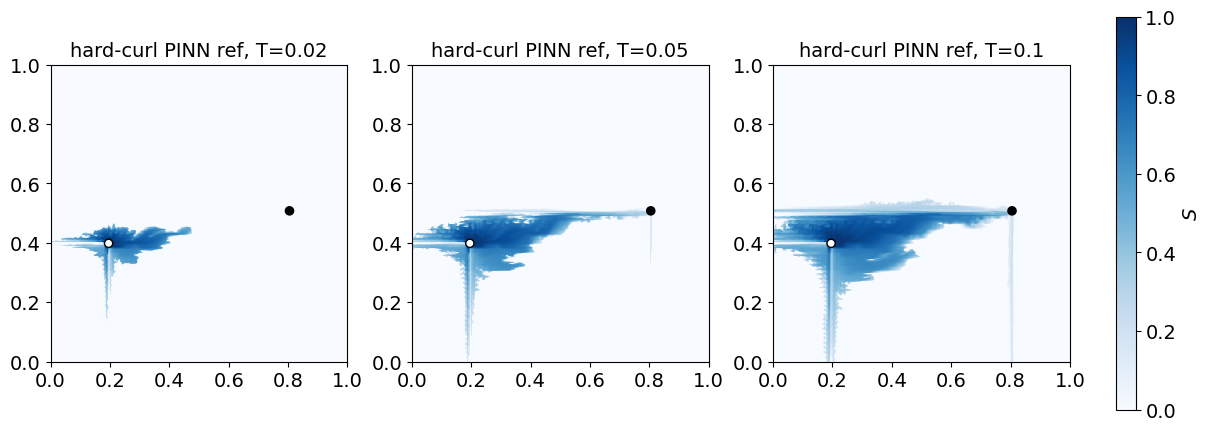

In [ ]:
# Plot hard-curl PINN saturation snapshots on the fine reference dual mesh.

def pinn_ref_dual_field_to_grid(S):
    return np.asarray(S, dtype=float).reshape((REF_NY + 1, REF_NX + 1))

pinn_ref_plot_keys = [f"T{T:g}" for T in sorted(np.unique(TRANSPORT_T_VALUES))]
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, len(pinn_ref_plot_keys), figsize=(max(4.0 * len(pinn_ref_plot_keys), 5.0), 4.2), squeeze=False, constrained_layout=True)
    axes = axes[0]
    im = None
    x_nodes_ref = np.linspace(xmin, xmax, REF_NX + 1)
    y_nodes_ref = np.linspace(ymin, ymax, REF_NY + 1)
    for ax, key in zip(axes, pinn_ref_plot_keys):
        im = ax.pcolormesh(x_nodes_ref, y_nodes_ref, pinn_ref_dual_field_to_grid(pinn_ref_transport_snapshots[key]), shading="auto", cmap="Blues", vmin=0.0, vmax=1.0)
        ax.scatter(source_points_effective64[:, 0], source_points_effective64[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
        ax.set_title(rf"hard-curl PINN ref, T={pinn_ref_transport_meta[key]['T']:g}")
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.grid(False)
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.03)
    cbar.set_label(r"$S$")
    plt.show()



Hard-curl PINN saturation error relative to CVFEM reference on the 512 dual mesh:
  CVFEM reference source: in-memory CVFEM transport
  T        L2 error       area RMSE    point RMSE    max|e|
  0.02     4.667103e-02 4.667103e-02 4.658286e-02 8.987149e-01
  0.05     8.281111e-02 8.281111e-02 8.267017e-02 8.798291e-01
  0.1      1.125831e-01 1.125831e-01 1.124091e-01 7.928355e-01


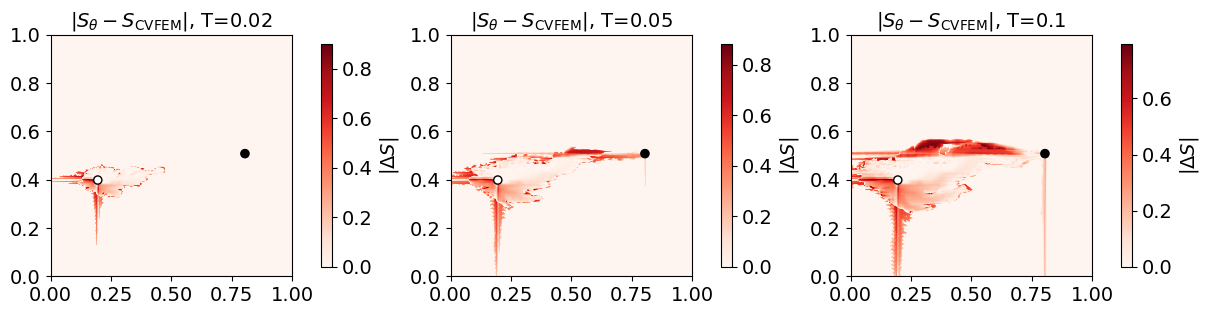

In [ ]:
# Absolute saturation error: hard-curl PINN reference transport versus CVFEM reference transport.
# This cell is independent of the CVFEM solve cells; it loads the saved CVFEM reference if needed.
PINN_CVFEM_ERROR_REF_FILE = OUTPUT_MAT

if "pinn_ref_transport_snapshots" not in globals():
    raise RuntimeError("Run the hard-curl PINN transport cell before this comparison cell.")
if "pinn_ref_dual_field_to_grid" not in globals():
    def pinn_ref_dual_field_to_grid(S):
        return np.asarray(S, dtype=float).reshape((REF_NY + 1, REF_NX + 1))


def _load_cvfem_reference_saturation_for_pinn_error():
    # Prefer the in-memory CVFEM transport if those cells were run; otherwise use the saved reference file.
    if "transport_snapshots" in globals() and isinstance(transport_snapshots, dict):
        return {str(k): np.asarray(v, dtype=float).reshape(-1) for k, v in transport_snapshots.items()}, "in-memory CVFEM transport"

    path = pathlib.Path(PINN_CVFEM_ERROR_REF_FILE)
    if not path.exists():
        raise FileNotFoundError(f"Missing CVFEM reference file: {path}")

    if path.suffix.lower() == ".mat":
        data = loadmat(path, squeeze_me=True, struct_as_record=False)
        S_all = np.asarray(data["S_ref_dual"], dtype=float)
        T_all = np.asarray(data["T_values"], dtype=float).reshape(-1)
    elif path.suffix.lower() == ".npz":
        with np.load(path) as data:
            S_all = np.asarray(data["S_ref_dual"], dtype=float)
            T_all = np.asarray(data["T_values"], dtype=float).reshape(-1)
    else:
        raise ValueError(f"Unsupported CVFEM reference file extension: {path.suffix}")

    if S_all.ndim == 1:
        S_all = S_all.reshape(1, -1)
    if S_all.shape[0] != T_all.size and S_all.shape[1] == T_all.size:
        S_all = S_all.T
    if S_all.shape[0] != T_all.size:
        raise ValueError(f"Could not align S_ref_dual shape {S_all.shape} with T_values size {T_all.size}")
    return {f"T{float(t):g}": S_all[i].reshape(-1) for i, t in enumerate(T_all)}, str(path)


cvfem_ref_saturation_by_key, cvfem_ref_source = _load_cvfem_reference_saturation_for_pinn_error()
pinn_cvfem_error_records = []
area_weights = np.asarray(pinn_ref_dual_pv, dtype=float).reshape(-1) / max(float(PHI_MATRIX), 1.0e-300)
area_total = float(np.sum(area_weights))

for key in [f"T{T:g}" for T in sorted(np.unique(TRANSPORT_T_VALUES))]:
    if key not in pinn_ref_transport_snapshots:
        print(f"Skipping {key}: missing hard-curl PINN snapshot")
        continue
    if key not in cvfem_ref_saturation_by_key:
        print(f"Skipping {key}: missing CVFEM reference snapshot")
        continue
    S_theta = np.asarray(pinn_ref_transport_snapshots[key], dtype=float).reshape(-1)
    S_cvfem = np.asarray(cvfem_ref_saturation_by_key[key], dtype=float).reshape(-1)
    if S_theta.size != S_cvfem.size:
        raise ValueError(f"Size mismatch for {key}: PINN={S_theta.size}, CVFEM={S_cvfem.size}")
    diff = S_theta - S_cvfem
    abs_diff = np.abs(diff)
    T_val = float(pinn_ref_transport_meta[key]["T"]) if "pinn_ref_transport_meta" in globals() and key in pinn_ref_transport_meta else float(key[1:])
    l2 = float(np.sqrt(np.sum((diff ** 2) * area_weights)))
    rmse_area = float(np.sqrt(np.sum((diff ** 2) * area_weights) / max(area_total, 1.0e-300)))
    rmse_plain = float(np.sqrt(np.mean(diff ** 2)))
    max_abs = float(np.max(abs_diff))
    pinn_cvfem_error_records.append((key, T_val, S_theta, S_cvfem, abs_diff, l2, rmse_area, rmse_plain, max_abs))

if not pinn_cvfem_error_records:
    raise RuntimeError("No matching PINN/CVFEM snapshots were found for the requested times.")

print("Hard-curl PINN saturation error relative to CVFEM reference on the 512 dual mesh:")
print(f"  CVFEM reference source: {cvfem_ref_source}")
print("  T        L2 error       area RMSE    point RMSE    max|e|")
for _key, _T, _S_theta, _S_cvfem, _abs_diff, _l2, _rmse_area, _rmse_plain, _max_abs in pinn_cvfem_error_records:
    print(f"  {_T:<8.4g} {_l2:12.6e} {_rmse_area:12.6e} {_rmse_plain:12.6e} {_max_abs:10.6e}")

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    ncols = len(pinn_cvfem_error_records)
    fig, axes = plt.subplots(1, ncols, figsize=(max(4.0 * ncols, 5.0), 4.2), squeeze=False, constrained_layout=True)
    axes = axes[0]
    x_nodes_ref = np.linspace(xmin, xmax, REF_NX + 1)
    y_nodes_ref = np.linspace(ymin, ymax, REF_NY + 1)
    for ax, (_key, _T, _S_theta, _S_cvfem, _abs_diff, _l2, _rmse_area, _rmse_plain, _max_abs) in zip(axes, pinn_cvfem_error_records):
        vmax = max(float(_max_abs), 1.0e-14)
        im = ax.pcolormesh(x_nodes_ref, y_nodes_ref, pinn_ref_dual_field_to_grid(_abs_diff), shading="auto", cmap="Reds", vmin=0.0, vmax=vmax)
        ax.scatter(source_points_effective64[:, 0], source_points_effective64[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
        ax.set_title(rf"$|S_\theta-S_{{\mathrm{{CVFEM}}}}|$, T={_T:g}")
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.grid(False)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cbar.set_label(r"$|\Delta S|$")
    plt.show()



In [ ]:
# Coarsen and export the hard-curl PINN reference transport result.
# The exported layout mirrors the CVFEM reference file and also includes S_theta_* aliases.
if "pinn_ref_dual_field_to_grid" not in globals():
    def pinn_ref_dual_field_to_grid(S):
        return np.asarray(S, dtype=float).reshape((REF_NY + 1, REF_NX + 1))


def pinn_ref_dual_interval_edges(n, h):
    centers = np.linspace(0.0, 1.0, n + 1)
    left = np.maximum(0.0, centers - 0.5 * h)
    right = np.minimum(1.0, centers + 0.5 * h)
    return left, right


def pinn_ref_overlap_matrix_dual_to_coarse(n_fine, n_coarse):
    h_f = 1.0 / n_fine
    h_c = 1.0 / n_coarse
    left, right = pinn_ref_dual_interval_edges(n_fine, h_f)
    W = np.zeros((n_coarse, n_fine + 1), dtype=float)
    for j in range(n_coarse):
        c0 = j * h_c
        c1 = (j + 1) * h_c
        W[j, :] = np.maximum(0.0, np.minimum(right, c1) - np.maximum(left, c0))
    return W


pinn_ref_Wx64 = pinn_ref_overlap_matrix_dual_to_coarse(REF_NX, BASE_NX)
pinn_ref_Wy64 = pinn_ref_overlap_matrix_dual_to_coarse(REF_NY, BASE_NY)
pinn_ref_weight_area = pinn_ref_Wy64 @ np.ones((REF_NY + 1, REF_NX + 1), dtype=float) @ pinn_ref_Wx64.T
print(f"Hard-curl coarsening weight area check: min={pinn_ref_weight_area.min():.8e}, max={pinn_ref_weight_area.max():.8e}, target={coarse_cell_area:.8e}")


def coarsen_pinn_ref_dual_to_64(S_dual):
    Sg = pinn_ref_dual_field_to_grid(S_dual)
    return (pinn_ref_Wy64 @ Sg @ pinn_ref_Wx64.T) / coarse_cell_area


pinn_ref_S64_by_key = {key: coarsen_pinn_ref_dual_to_64(S) for key, S in pinn_ref_transport_snapshots.items()}

PINN_REF_OUTPUT_NPZ = DATA_FILE.parent / f"{PINN_REF_OUTPUT_BASENAME}.npz"
PINN_REF_OUTPUT_MAT = DATA_FILE.parent / f"{PINN_REF_OUTPUT_BASENAME}.mat"
PINN_REF_OUTPUT_NPZ.parent.mkdir(parents=True, exist_ok=True)
pinn_ref_keys_sorted = [f"T{T:g}" for T in sorted(np.unique(TRANSPORT_T_VALUES))]
pinn_ref_S_dual = np.vstack([pinn_ref_transport_snapshots[k].reshape(1, -1) for k in pinn_ref_keys_sorted])
pinn_ref_S64 = np.vstack([pinn_ref_S64_by_key[k].reshape(1, -1) for k in pinn_ref_keys_sorted])
pinn_ref_T_values = np.array([pinn_ref_transport_meta[k]["T"] for k in pinn_ref_keys_sorted], dtype=float)
pinn_ref_meta_nsteps = np.array([pinn_ref_transport_meta[k]["nsteps_total"] for k in pinn_ref_keys_sorted], dtype=np.int64)
pinn_ref_meta_last_dt = np.array([pinn_ref_transport_meta[k]["last_dt"] for k in pinn_ref_keys_sorted], dtype=float)
pinn_ref_meta_target_dt = np.array([pinn_ref_transport_meta[k]["dt_target"] for k in pinn_ref_keys_sorted], dtype=float)
pinn_ref_meta_effective_cfl = np.array([pinn_ref_transport_meta[k]["effective_cfl"] for k in pinn_ref_keys_sorted], dtype=float)
pinn_ref_meta_balance_pct = np.array([pinn_ref_transport_meta[k]["water_balance_error_pct"] for k in pinn_ref_keys_sorted], dtype=float)

np.savez_compressed(
    PINN_REF_OUTPUT_NPZ,
    kappa64=kappa64.reshape(-1),
    kappa_ref=kappa_ref,
    checkpoint=str(PINN_REF_CHECKPOINT),
    dual_owner=pinn_ref_dual_owner,
    dual_neigh=pinn_ref_dual_neigh,
    dual_flux=pinn_ref_dual_flux,
    dual_pv=pinn_ref_dual_pv,
    dual_source_rate=pinn_ref_dual_source_rate,
    face_p1=pinn_ref_face_p1,
    face_p2=pinn_ref_face_p2,
    face_normal=pinn_ref_face_normal,
    single_phase_residual=pinn_ref_residual,
    S_ref_dual=pinn_ref_S_dual,
    S_ref64=pinn_ref_S64,
    S_theta_dual=pinn_ref_S_dual,
    S_theta64=pinn_ref_S64,
    T_values=pinn_ref_T_values,
    meta_nsteps=pinn_ref_meta_nsteps,
    meta_last_dt=pinn_ref_meta_last_dt,
    meta_target_dt=pinn_ref_meta_target_dt,
    meta_dt_cfl=np.array([pinn_ref_transport_meta[pinn_ref_keys_sorted[0]]["dt_cfl"]], dtype=float),
    meta_effective_cfl=pinn_ref_meta_effective_cfl,
    meta_dt_source=np.array([pinn_ref_transport_meta[pinn_ref_keys_sorted[0]]["dt_source"]]),
    meta_balance_pct=pinn_ref_meta_balance_pct,
    source_points_requested=SOURCE_POINTS_REQUESTED,
    source_points_effective64=source_points_effective64,
    source_cell_ids64=source_cell_ids64,
    source_rates=SOURCE_RATES,
    base_shape=np.array([BASE_NY, BASE_NX], dtype=np.int64),
    ref_shape=np.array([REF_NY, REF_NX], dtype=np.int64),
    ref_node_shape=np.array([REF_NY + 1, REF_NX + 1], dtype=np.int64),
)

_mat_payload = {
    "kappa64": kappa64,
    "checkpoint": np.array(str(PINN_REF_CHECKPOINT)),
    "dual_owner": pinn_ref_dual_owner + 1,
    "dual_neigh": np.where(pinn_ref_dual_neigh >= 0, pinn_ref_dual_neigh + 1, 0),
    "dual_flux": pinn_ref_dual_flux,
    "dual_pv": pinn_ref_dual_pv,
    "dual_source_rate": pinn_ref_dual_source_rate,
    "face_p1": pinn_ref_face_p1,
    "face_p2": pinn_ref_face_p2,
    "face_centroid": 0.5 * (pinn_ref_face_p1 + pinn_ref_face_p2),
    "face_normal": pinn_ref_face_normal,
    "single_phase_residual": pinn_ref_residual,
    "S_ref_dual": pinn_ref_S_dual,
    "S_ref64": pinn_ref_S64,
    "S_theta_dual": pinn_ref_S_dual,
    "S_theta64": pinn_ref_S64,
    "T_values": pinn_ref_T_values,
    "meta_nsteps": pinn_ref_meta_nsteps,
    "meta_last_dt": pinn_ref_meta_last_dt,
    "meta_target_dt": pinn_ref_meta_target_dt,
    "meta_dt_cfl": np.array([pinn_ref_transport_meta[pinn_ref_keys_sorted[0]]["dt_cfl"]], dtype=float),
    "meta_effective_cfl": pinn_ref_meta_effective_cfl,
    "meta_dt_source": np.array(pinn_ref_transport_meta[pinn_ref_keys_sorted[0]]["dt_source"]),
    "meta_balance_pct": pinn_ref_meta_balance_pct,
    "source_points_requested": SOURCE_POINTS_REQUESTED,
    "source_points_effective64": source_points_effective64,
    "source_cell_ids64": source_cell_ids64 + 1,
    "source_rates": SOURCE_RATES,
    "README": np.array("Hard-curl PINN q_theta transport on the 512 CVFEM/MRST reference dual mesh; 64-cell P0 kappa/source convention."),
}
for _i, _key in enumerate(pinn_ref_keys_sorted):
    _code = int(round(float(pinn_ref_T_values[_i]) * 100.0))
    _mat_payload[f"sw_T{_code:03d}"] = pinn_ref_S_dual[_i]
    _mat_payload[f"sw_T{_code:03d}_64"] = pinn_ref_S64[_i]

savemat(PINN_REF_OUTPUT_MAT, _mat_payload, do_compression=True)

print("Hard-curl PINN 64-cell coarsened saturation range:")
for key in pinn_ref_keys_sorted:
    C = pinn_ref_S64_by_key[key]
    print(f"  {key:<7} min={np.min(C):.6e}, max={np.max(C):.6e}, mean={np.mean(C):.6e}")
print(f"Saved hard-curl PINN reference: {PINN_REF_OUTPUT_NPZ}")
print(f"Saved compact MATLAB hard-curl PINN reference: {PINN_REF_OUTPUT_MAT}")



Hard-curl coarsening weight area check: min=2.44140625e-04, max=2.44140625e-04, target=2.44140625e-04
Hard-curl PINN 64-cell coarsened saturation range:
  T0.02   min=0.000000e+00, max=9.648805e-01, mean=1.996751e-02
  T0.05   min=0.000000e+00, max=9.730834e-01, mean=4.832037e-02
  T0.1    min=0.000000e+00, max=9.742231e-01, mean=7.774351e-02
Saved hard-curl PINN reference: case3_ecmor/case3_hardcurl_pinn_reference_spe10_512.npz
Saved compact MATLAB hard-curl PINN reference: case3_ecmor/case3_hardcurl_pinn_reference_spe10_512.mat
